# Empirical firn-warming relationship from glenglat

**Goal**: Derive the offset ΔT_firn = T_measured_at_depth − T_mean_annual as a function of T_mean_annual  
and/or accumulation rate, using measured englacial temperatures from the global glenglat database.

**Context**: GloGEMflow initialises its firn/ice temperature column isothermally (every layer set to the  
mean annual air temperature). This is physically wrong — in the accumulation zone, latent heat from  
refreezing warms the subsurface 1–5 °C above T_mean_annual. We want to quantify this firn-warming  
correction per elevation band and use it to build a physically-informed depth profile for the spin-up.

**Reference**: Cuffey & Paterson (2010), §9.2; Suter et al. (2001, J. Glaciol.); Lüthi & Funk (2001).

## Section 0 — Setup

In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
from pathlib import Path

# Paths — resolve relative to repo root (one level up from notebooks/)
REPO_ROOT = Path().resolve().parent
GLENGLAT  = REPO_ROOT / 'glenglat/data'

# Depth range considered to be seasonal-wave-attenuated
DEPTH_MIN = 10.0   # m
DEPTH_MAX = 25.0   # m  (slightly wider than 15 m to capture more sites)

# Temperature threshold: discard sites warmer than this (likely temperate, T_15m = 0 °C at PMP)
TMEAN_MAX = -1.0   # °C

print(f'glenglat data path: {GLENGLAT}')
assert GLENGLAT.exists(), f'glenglat/data not found — run: git submodule update --init'

glenglat data path: /home/jabeer/projects/glogemflow_development/glogemflow_icetemp/glenglat/data


## Section 1 — Explore glenglat

In [170]:
# Load the three main tables
boreholes    = pd.read_csv(GLENGLAT / 'borehole.csv')
profiles     = pd.read_csv(GLENGLAT / 'profile.csv')
measurements = pd.read_csv(GLENGLAT / 'measurement.csv')

print('=== borehole.csv ===')
print(f'Shape: {boreholes.shape}')
print(boreholes.dtypes)
print()
print('=== profile.csv ===')
print(f'Shape: {profiles.shape}')
print(profiles.dtypes)
print()
print('=== measurement.csv ===')
print(f'Shape: {measurements.shape}')
print(measurements.dtypes)

=== borehole.csv ===
Shape: (835, 22)
id                           int64
source_id                      str
glacier_name                   str
glims_id                       str
location_origin                str
latitude                   float64
longitude                  float64
elevation_origin               str
elevation                  float64
mass_balance_area              str
label                          str
date_min                       str
date_max                       str
drill_method                   str
ice_depth                  float64
depth                      float64
to_bed                      object
temperature_uncertainty    float64
notes                          str
curator                        str
investigators                  str
funding                        str
dtype: object

=== profile.csv ===
Shape: (1842, 10)
borehole_id             int64
id                      int64
source_id                 str
measurement_origin        str
date_min           

In [171]:
# Preview key columns
print('--- borehole sample ---')
display(boreholes[['id','glacier_name','latitude','longitude','elevation','mass_balance_area','date_min','date_max']].head(10))

print('--- profile sample ---')
display(profiles[['borehole_id','id','date_min','date_max','equilibrium']].head(10))

print('--- measurement sample ---')
display(measurements.head(10))

--- borehole sample ---


,id,glacier_name,latitude,longitude,elevation,mass_balance_area,date_min,date_max
0,1,Grenzgletscher,45.930329,7.875013,4450.0,accumulation,1977-08-20,1977-08-20
1,2,Grenzgletscher,45.967331,7.797442,2600.0,ablation,NaN,1979-12-31
2,3,Grenzgletscher,45.973722,7.763328,2500.0,ablation,NaN,1980-12-31
3,4,White Glacier,79.530780,-91.001760,1447.0,accumulation,1979-07-13,1979-07-13
4,5,White Glacier,79.472070,-90.756630,625.0,ablation,1980-05-20,1980-05-20
5,6,White Glacier,79.437240,-90.643890,230.0,ablation,1979-07-23,1979-07-23
6,7,Illimani Volcano,-16.650000,-67.783333,6340.0,accumulation,1999-06-01,1999-06-03
7,8,Glacier des Bossons,45.842675,6.843812,4300.0,accumulation,1999-01-01,1999-12-31
8,9,Glacier des Bossons,45.842616,6.843717,4300.0,accumulation,2011-01-01,2011-12-31
9,10,Glacier des Bossons,45.842190,6.846699,4245.0,accumulation,1994-01-01,1994-06-30


--- profile sample ---


,borehole_id,id,date_min,date_max,equilibrium
0,1,1,1977-08-21,1977-08-21,true
1,2,1,1979-01-01,1979-12-31,true
2,3,1,1980-01-01,1980-12-31,true
3,4,1,1979-07-13,1979-08-13,true
4,5,1,1980-05-20,1980-06-20,true
5,6,1,1979-07-23,1979-08-23,true
6,7,1,1999-06-04,1999-06-05,true
7,8,1,1999-01-01,1999-12-31,true
8,9,1,2011-01-01,2011-12-31,true
9,10,1,1994-06-01,1994-06-30,true


--- measurement sample ---


,borehole_id,profile_id,depth,temperature
0,1,1,20.000,-14.500
1,1,1,50.000,-13.800
2,2,1,11.305,-2.958
3,2,1,18.632,-3.355
4,2,1,29.399,-3.618
5,2,1,43.986,-3.709
6,2,1,63.164,-3.667
7,2,1,83.880,-3.662
8,2,1,107.280,-3.637
9,2,1,127.241,-3.765


In [172]:
# How many boreholes are in the accumulation vs ablation zone?
print(boreholes['mass_balance_area'].value_counts())
print()
# Elevation distribution
print(boreholes['elevation'].describe())
print()
# Measurement depth distribution
print('Depth stats:')
print(measurements['depth'].describe())

mass_balance_area
accumulation    291
ablation        208
equilibrium      33
Name: count, dtype: int64

count     835.000000
mean     2682.968837
std      1822.400535
min        14.000000
25%       770.500000
50%      2650.000000
75%      4200.000000
max      7200.000000
Name: elevation, dtype: float64

Depth stats:
count    16939.000000
mean        31.695183
std         68.126805
min        -10.376000
25%          2.773500
50%          8.000000
75%         22.500000
max        743.032100
Name: depth, dtype: float64


## Section 2 — ERA5 T_mean_annual per borehole

Mean annual air temperature (MAAT) at each borehole elevation is computed in two steps:

**Temperature (ERA5 global file, 1940–2025)**
1. Find the nearest ERA5 grid cell (0.25° resolution) by lat/lon distance.
2. Get the ERA5 surface elevation for that cell from `era_hgt.nc` (z / g [m]).
3. Compute the mean ERA5 2m temperature (`t2m`) for the **`LOOKBACK_YRS` years ending
   the year before the borehole measurement** (`profile_date_min` year − `LOOKBACK_YRS`
   to year − 1). Falls back to the 1981–2010 climatology if fewer than 5 years available.

**Lapse-rate correction (GloGEM `.mdi` tgrad files)**
4. Find the nearest grid point in GloGEM's regional `tgrad_<Region>.mdi` files (0.5°
   regional grids, same files used by GloGEM). Take the annual-mean lapse rate `tg` [K/m].
5. Apply: `T_maat = T_ERA5(window) + tg × (z_borehole − z_ERA5_cell)`

This hybrid approach combines:
- The long ERA5 temperature record (1940–2025) — unavailable in the `.mdi` files (1979–2019)
- GloGEM's spatially-varying lapse rates — better than a fixed standard ELR

Profiles before `PROFILE_YEAR_MIN = 1950` are excluded (insufficient prior ERA5 data).
Regions without `.mdi` tgrad files (`LowLatitudes`, `Antarctic`) use the nearest
available tgrad grid point from an adjacent region via nearest-neighbour.

In [173]:
import xarray as xr
import numpy as np
from pathlib import Path

ERA5_BASE        = Path('/itet-stor/jabeer/glogem/climatedata/reanalysis/monthly/ERA5')
ERA5_TEMP_NC     = ERA5_BASE / 'files/era5_temp_19402025.nc'
ERA5_HGT_NC      = ERA5_BASE / 'files/era_hgt.nc'
LOOKBACK_YRS     = 10
PROFILE_YEAR_MIN = 1950
REF_YEARS        = (1981, 2010)

REGIONS_MISSING  = {'LowLatitudes', 'Antarctic'}

# ── Climatic regime classification (3-regime catalogue) ───────────────────────
# Alaska: assigned Temperate/Maritime (coastal ranges dominate glacier volume)
# Iceland: assigned Temperate/Maritime (Vatnajökull is the dominant ice mass)
# NorthAsia: assigned Sub-Continental (Altai/Sayan ranges dominate glenglat coverage)
REGIME_MAP = {
    'ArcticCanadaN': 'Polar / High-Arctic',
    'ArcticCanadaS': 'Polar / High-Arctic',
    'Svalbard':      'Polar / High-Arctic',
    'RussianArctic': 'Polar / High-Arctic',
    'Greenland':     'Polar / High-Arctic',
    'Iceland':       'Temperate / Maritime',
    'Alaska':        'Temperate / Maritime',
    'WesternCanada': 'Temperate / Maritime',
    'CentralEurope': 'Temperate / Maritime',
    'SouthernAndes': 'Temperate / Maritime',
    'NewZealand':    'Temperate / Maritime',
    'Scandinavia':   'Sub-Continental',
    'NorthAsia':     'Sub-Continental',
    'Caucasus':      'Sub-Continental',
    'CentralAsia':   'Sub-Continental',
    'SouthAsiaWest': 'Sub-Continental',
    'SouthAsiaEast': 'Sub-Continental',
    'LowLatitudes':  'Sub-Continental',
    'Antarctic':     'Polar / High-Arctic',
}

# ── 1. Load tgrad from GloGEM .mdi files ─────────────────────────────────────
def _parse_mdi_tgrad(fp):
    with open(fp) as f:
        f.readline()
        vals = np.array(f.read().split(), dtype=float)
    i = 0
    nm    = int(vals[i]); i += 1
    nlons = int(vals[i]); i += 1
    nlats = int(vals[i]); i += 1
    i += 1
    rmon  = vals[i:i+nm];    i += nm
    rlon  = vals[i:i+nlons]; i += nlons
    rlat  = vals[i:i+nlats]; i += nlats
    rtg   = vals[i:i+nm*nlons*nlats].reshape(nm, nlons, nlats)
    rlon[rlon >= 180] -= 360
    return dict(rlon=rlon, rlat=rlat, rtg=rtg)

print('Loading tgrad from .mdi files...')
tg_lons, tg_lats, tg_vals, tg_regions = [], [], [], []
tg_monthly = []   # (n_pts, 12) monthly lapse rates

for reg_dir in sorted(ERA5_BASE.iterdir()):
    if reg_dir.name in ('files', *REGIONS_MISSING) or not reg_dir.is_dir():
        continue
    tf = reg_dir / f'tgrad_{reg_dir.name}.mdi'
    if not tf.exists():
        continue
    t = _parse_mdi_tgrad(tf)
    tg_ann = t['rtg'].mean(axis=0)
    nlons, nlats = tg_ann.shape
    tg_lons.extend(np.tile(t['rlon'][:, np.newaxis], (1, nlats)).ravel())
    tg_lats.extend(np.tile(t['rlat'][np.newaxis, :], (nlons, 1)).ravel())
    tg_vals.extend(tg_ann.ravel())
    tg_regions.extend([reg_dir.name] * (nlons * nlats))
    tg_monthly.extend(
        t['rtg'].reshape(t['rtg'].shape[0], nlons * nlats).T.tolist())
    print(f'  {reg_dir.name:<18}  grid {nlons}×{nlats}')

tg_lons    = np.array(tg_lons)
tg_lats    = np.array(tg_lats)
tg_vals    = np.array(tg_vals)
tg_regions = np.array(tg_regions)
tg_monthly = np.array(tg_monthly)   # shape (n_grid_points, 12)
print(f'tgrad grid points: {len(tg_lons):,}')

def _nearest_tgrad(lat, lon):
    dists = np.sqrt((tg_lats - lat)**2 + (tg_lons - lon)**2)
    return tg_vals[np.argmin(dists)]

def _nearest_tgrad_monthly(lat, lon):
    dists = np.sqrt((tg_lats - lat)**2 + (tg_lons - lon)**2)
    return tg_monthly[np.argmin(dists)]   # 12-element array (K/m)

def _nearest_region(lat, lon):
    dists = np.sqrt((tg_lats - lat)**2 + (tg_lons - lon)**2)
    return REGIME_MAP.get(tg_regions[np.argmin(dists)], 'Other')

def _nearest_glogem_region(lat, lon):
    dists = np.sqrt((tg_lats - lat)**2 + (tg_lons - lon)**2)
    return tg_regions[np.argmin(dists)]

# ── 2. Load ERA5 global temperature file (lazy) ───────────────────────────────
print('\nOpening ERA5 global temperature (lazy)...')
ds_t = xr.open_dataset(ERA5_TEMP_NC)
ds_h = xr.open_dataset(ERA5_HGT_NC)

era5_lat = ds_t['latitude'].values
era5_lon = ds_t['longitude'].values
era5_hgt = ds_h['z'].values[0] / 9.80665

era5_time = ds_t['valid_time'].values
era5_year = era5_time.astype('datetime64[Y]').astype(int) + 1970

print(f'ERA5 temperature: {era5_year[0]}–{era5_year[-1]}  ({len(era5_year)} months)')
print(f'Grid: {len(era5_lat)} lat × {len(era5_lon)} lon  (0.25° resolution)')

# ── 3. Per-point annual mean cache ────────────────────────────────────────────
_era5_cache = {}

def _load_point(ilat, ilon):
    key = (ilat, ilon)
    if key not in _era5_cache:
        ts_C = ds_t['t2m'].isel(latitude=ilat, longitude=ilon).values - 273.15
        uniq_yrs = np.array([y for y in np.unique(era5_year) if (era5_year == y).sum() >= 12])
        ann_t    = np.array([ts_C[era5_year == y].mean() for y in uniq_yrs])
        _era5_cache[key] = (uniq_yrs, ann_t)
    return _era5_cache[key]

# ── 4. T_maat lookup: ERA5 temperature + .mdi tgrad lapse rate ───────────────
def era5_tmaat(lat, lon, elev, year=None):
    """T_maat at borehole elevation.
    Temperature from ERA5 global (1940–2025); lapse-rate from GloGEM .mdi tgrad.
    year: averages LOOKBACK_YRS years ending year-1; falls back to REF_YEARS climatology.
    """
    if np.isnan(lat) or np.isnan(lon) or np.isnan(elev):
        return np.nan
    ilat = int(np.argmin(np.abs(era5_lat - lat)))
    ilon = int(np.argmin(np.abs(era5_lon - (lon % 360))))
    ann_yrs, ann_t = _load_point(ilat, ilon)

    if year is not None:
        mask = (ann_yrs >= year - LOOKBACK_YRS) & (ann_yrs <= year - 1)
        t_grid = ann_t[mask].mean() if mask.sum() >= 5 else ann_t[
            (ann_yrs >= REF_YEARS[0]) & (ann_yrs <= REF_YEARS[1])].mean()
    else:
        t_grid = ann_t[(ann_yrs >= REF_YEARS[0]) & (ann_yrs <= REF_YEARS[1])].mean()

    return t_grid + _nearest_tgrad(lat, lon) * (elev - era5_hgt[ilat, ilon])

# ── Borehole-level T_maat (1981–2010 ref, for sanity check) ──────────────────
print('\nComputing borehole-level T_maat (1981–2010 ref)...')
boreholes['T_maat'] = [
    era5_tmaat(row.latitude, row.longitude, row.elevation)
    for _, row in boreholes.iterrows()
]
print(f'T_maat computed for {boreholes["T_maat"].notna().sum()} boreholes')
print(boreholes['T_maat'].describe().round(2))
print()
print('Sanity check — highest accumulation sites:')
print(
    boreholes[boreholes['mass_balance_area'] == 'accumulation']
    [['glacier_name', 'elevation', 'T_maat']]
    .sort_values('elevation', ascending=False)
    .head(8)
    .to_string(index=False)
)

Loading tgrad from .mdi files...
  Alaska              grid 217×89
  ArcticCanadaN       grid 160×55
  ArcticCanadaS       grid 121×80
  Caucasus            grid 87×65
  CentralAsia         grid 166×89
  CentralEurope       grid 76×41
  Greenland           grid 255×115
  Iceland             grid 60×31
  NewZealand          grid 52×43
  RussianArctic       grid 294×56
  Scandinavia         grid 134×64
  SouthAsiaEast       grid 121×39
  SouthAsiaWest       grid 72×48
  SouthernAndes       grid 50×137
  Svalbard            grid 184×59
  WesternCanada       grid 132×176
tgrad grid points: 168,912

Opening ERA5 global temperature (lazy)...
ERA5 temperature: 1940–2025  (1032 months)
Grid: 721 lat × 1440 lon  (0.25° resolution)

Computing borehole-level T_maat (1981–2010 ref)...
T_maat computed for 835 boreholes
count    835.00
mean     -11.18
std        4.97
min      -27.61
25%      -13.89
50%      -11.26
75%       -7.49
max        1.57
Name: T_maat, dtype: float64

Sanity check — highest a

## Section 2 — Filter for cold/polythermal glaciers in the accumulation zone

In [174]:
# Keep only equilibrium profiles from PROFILE_YEAR_MIN onwards
# Note: equilibrium column is a string ('true'/'false'), not a Python bool
profile_year = pd.to_datetime(profiles['date_min'], errors='coerce').dt.year
eq_profiles = profiles[
    (profiles['equilibrium'] == 'true') &
    (profile_year >= PROFILE_YEAR_MIN)
][['borehole_id', 'id', 'date_min', 'date_max']].copy()
eq_profiles.columns = ['borehole_id', 'profile_id', 'profile_date_min', 'profile_date_max']

print(f'Equilibrium profiles: {len(eq_profiles)} of {len(profiles)}')
print(f'  (filtered to {PROFILE_YEAR_MIN}+ to ensure ≥{LOOKBACK_YRS} yrs ERA5 prior data)')
print()
print('Profile year distribution:')
yr = pd.to_datetime(eq_profiles['profile_date_min'], errors='coerce').dt.year
print(yr.describe().astype(int).to_string())

# Merge measurements with profiles (keep only equilibrium)
meas_eq = measurements.merge(eq_profiles, on=['borehole_id', 'profile_id'], how='inner')
print(f'\nMeasurements on equilibrium profiles ≥{PROFILE_YEAR_MIN}: {len(meas_eq)}')

# Filter depth range
meas_depth = meas_eq[(meas_eq['depth'] >= DEPTH_MIN) & (meas_eq['depth'] <= DEPTH_MAX)].copy()
print(f'Measurements at {DEPTH_MIN}–{DEPTH_MAX} m depth: {len(meas_depth)}')

Equilibrium profiles: 577 of 1842
  (filtered to 1950+ to ensure ≥10 yrs ERA5 prior data)

Profile year distribution:
count     577
mean     1983
std        22
min      1957
25%      1959
50%      1980
75%      2005
max      2023

Measurements on equilibrium profiles ≥1950: 6744
Measurements at 10.0–25.0 m depth: 1442


In [175]:
# T_maat is now in boreholes['T_maat'] (see Section 2 above).
# Merge it into the full equilibrium measurement table here so it
# propagates into the per-profile extraction below.
meas_all = measurements.merge(eq_profiles, on=['borehole_id', 'profile_id'], how='inner')
meas_all = meas_all.merge(
    boreholes[['id', 'glacier_name', 'latitude', 'longitude',
               'elevation', 'mass_balance_area', 'T_maat']],
    left_on='borehole_id', right_on='id', how='left'
)
print(f'Equilibrium measurements with metadata: {len(meas_all)}')
print(f'T_maat available for {meas_all["T_maat"].notna().mean()*100:.1f}% of rows')

Equilibrium measurements with metadata: 6744
T_maat available for 100.0% of rows


In [176]:
def extract_shallow(grp):
    """Extract measurement closest to 15 m (10–30 m) from one equilibrium profile."""
    grp = grp.sort_values('depth')
    shallow = grp[(grp['depth'] >= 10) & (grp['depth'] <= 30)]
    if len(shallow) == 0:
        return None
    row = shallow.loc[(shallow['depth'] - 15.0).abs().idxmin()]

    lat      = grp['latitude'].iloc[0]
    lon      = grp['longitude'].iloc[0]
    elev     = grp['elevation'].iloc[0]
    date_str = grp['profile_date_min'].iloc[0]

    try:
        meas_year = int(str(date_str)[:4])
    except (ValueError, TypeError):
        meas_year = None

    t_maat = era5_tmaat(lat, lon, elev, year=meas_year)

    return pd.Series({
        'glacier_name':      grp['glacier_name'].iloc[0],
        'latitude':          lat,
        'longitude':         lon,
        'elevation':         elev,
        'mass_balance_area': grp['mass_balance_area'].iloc[0],
        'regime':            _nearest_region(lat, lon),
        'glogem_region':     _nearest_glogem_region(lat, lon),
        'T_maat':            t_maat,
        'profile_date_min':  date_str,
        'T_shallow_depth':   float(row['depth']),
        'T_shallow':         float(row['temperature']),
    })

paired = (
    meas_all
    .groupby(['borehole_id', 'profile_id'])
    .apply(extract_shallow)
    .dropna()
    .reset_index()
)
print(f'Profiles with shallow (10–30 m) measurement: {len(paired)}')
print(f'  ERA5 grid cells loaded into cache: {len(_era5_cache)}')
print()
print('Regime counts (all zones):')
print(paired['regime'].value_counts().to_string())
print()
print('GloGEM region counts (all zones):')
print(paired['glogem_region'].value_counts().to_string())

Profiles with shallow (10–30 m) measurement: 363
  ERA5 grid cells loaded into cache: 201

Regime counts (all zones):
regime
Temperate / Maritime    143
Sub-Continental         114
Polar / High-Arctic     106

GloGEM region counts (all zones):
glogem_region
CentralEurope    129
CentralAsia      114
ArcticCanadaN     41
RussianArctic     34
Svalbard          30
SouthernAndes      9
WesternCanada      4
Greenland          1
Alaska             1


## Section 3 — Compute and visualise ΔT_firn

**ΔT_firn definition**:

$$\Delta T_{firn} = T_{shallow} - T_{MAAT}$$

where $T_{shallow}$ is the measured englacial temperature at 10–30 m depth (below the seasonal
oscillation layer) and $T_{MAAT}$ is the ERA5 mean annual air temperature extracted with
GloGEM's `.mdi` procedure and lapse-rate corrected to the borehole elevation.

**Temporal reference for T_MAAT**: To avoid aliasing secular warming into ΔT_firn, each profile
uses the mean of the `LOOKBACK_YRS` years **ending the year before the measurement date**
(falling back to the 1981–2010 climatology for measurements before the ERA5 .mdi coverage).

In the accumulation zone, latent heat from refreezing warms the subsurface **above** $T_{MAAT}$,
so $\Delta T_{firn} > 0$ is the expected signature (Suter et al. 2001; Cuffey & Paterson 2010, §9.2).
In the ablation zone there is no firn, no systematic refreezing, so $\Delta T_{firn} \approx 0$.

In [177]:
paired['dT_firn'] = paired['T_shallow'] - paired['T_maat']

# All sites — no filter on mass balance zone or thermal regime
profiles = paired.copy()
print(f'Total profiles: {len(profiles)}')
print()
print('dT_firn statistics (all zones, all thermal regimes):')
print(profiles['dT_firn'].describe().round(3))
print()
print('Mass balance area breakdown:')
print(profiles['mass_balance_area'].value_counts(dropna=False).to_string())

Total profiles: 363

dT_firn statistics (all zones, all thermal regimes):
count    363.000
mean       6.079
std        3.390
min       -1.631
25%        3.759
50%        6.232
75%        8.354
max       14.406
Name: dT_firn, dtype: float64

Mass balance area breakdown:
mass_balance_area
accumulation    221
ablation        108
equilibrium      34


Boreholes with measurement at 14–16 m: 324
Actual depth range: 14.00–16.00 m

Mass balance area breakdown:
mass_balance_area
accumulation    145
NaN             103
ablation         64
equilibrium      12


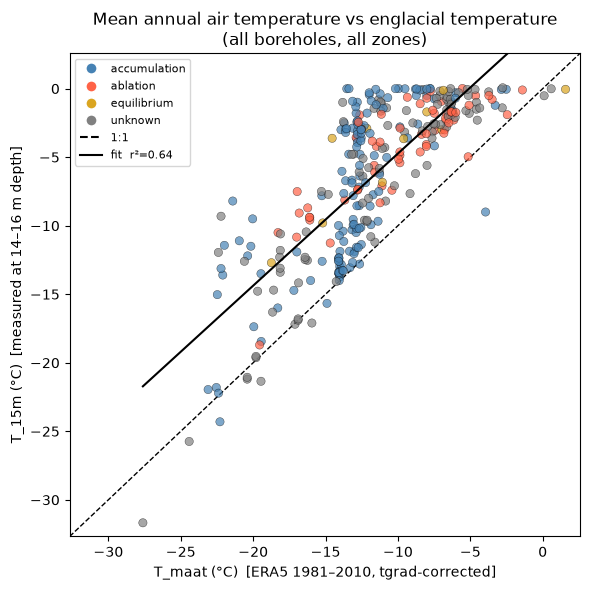


Regression: T_15m = 4.907 + 0.964 · T_maat
  r² = 0.638,  n = 324
  p = 5.65e-73,  SE(slope) = 0.0405


In [178]:
# ── Reproduce glenglat paper: T_maat vs T_15m — entire dataset ────────────────
# Uses raw measurements table (all profiles, no equilibrium/year/profiles filter).
# Selects the measurement closest to 15 m (within ±1 m) per borehole.
# T_maat from cell-8 (1981–2010 climatology, consistent with a static MAAT estimate).

m15 = measurements.copy()
m15['dist_15'] = (m15['depth'] - 15.0).abs()
m15 = m15[m15['dist_15'] <= 1.0]                               # ±1 m of 15 m
m15 = m15.loc[m15.groupby('borehole_id')['dist_15'].idxmin()]  # one per borehole

m15 = m15.merge(
    boreholes[['id', 'glacier_name', 'mass_balance_area', 'T_maat']],
    left_on='borehole_id', right_on='id', how='left'
).dropna(subset=['T_maat', 'temperature'])

print(f'Boreholes with measurement at 14–16 m: {len(m15)}')
print(f'Actual depth range: {m15["depth"].min():.2f}–{m15["depth"].max():.2f} m')
print()
print('Mass balance area breakdown:')
print(m15['mass_balance_area'].value_counts(dropna=False).to_string())

fig, ax = plt.subplots(figsize=(6, 6))
colours_all = m15['mass_balance_area'].map(
    {'accumulation': 'steelblue', 'ablation': 'tomato', 'equilibrium': 'goldenrod'}
).fillna('grey')
ax.scatter(m15['T_maat'], m15['temperature'], c=colours_all,
           alpha=0.7, edgecolors='k', linewidths=0.3, zorder=3)

lim = [min(m15['T_maat'].min(), m15['temperature'].min()) - 1,
       max(m15['T_maat'].max(), m15['temperature'].max()) + 1]
ax.plot(lim, lim, 'k--', lw=1, zorder=2, label='1:1  (ΔT_firn = 0)')

sl, ic, r, p_val, se = stats.linregress(m15['T_maat'], m15['temperature'])
x_fit = np.linspace(m15['T_maat'].min(), m15['T_maat'].max(), 100)
ax.plot(x_fit, ic + sl * x_fit, 'k-', lw=1.5, zorder=4,
        label=f'T_15m = {ic:.2f} + {sl:.2f}·T_maat  (r²={r**2:.2f})')

ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('T_maat (°C)  [ERA5 1981–2010, tgrad-corrected]')
ax.set_ylabel('T_15m (°C)  [measured at 14–16 m depth]')
ax.set_title('Mean annual air temperature vs englacial temperature\n(all boreholes, all zones)')

from matplotlib.lines import Line2D
zone_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', label='accumulation', markersize=8),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',    label='ablation',     markersize=8),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='goldenrod', label='equilibrium',  markersize=8),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='grey',      label='unknown',      markersize=8),
    Line2D([0],[0], color='k', ls='--', label='1:1'),
    Line2D([0],[0], color='k', ls='-',  label=f'fit  r²={r**2:.2f}'),
]
ax.legend(handles=zone_handles, fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('../figures/fig_00_T15m_vs_Tmaat.pdf', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nRegression: T_15m = {ic:.3f} + {sl:.3f} · T_maat')
print(f'  r² = {r**2:.3f},  n = {len(m15)}')
print(f'  p = {p_val:.2e},  SE(slope) = {se:.4f}')

Original (range-inflated) r²  = 0.638   RMSE = 3.47 °C  n = 324
1:1 line r²                    = -0.216
Within-4°C-bin r²          = 0.148   RMSE = 3.19 °C  n = 319


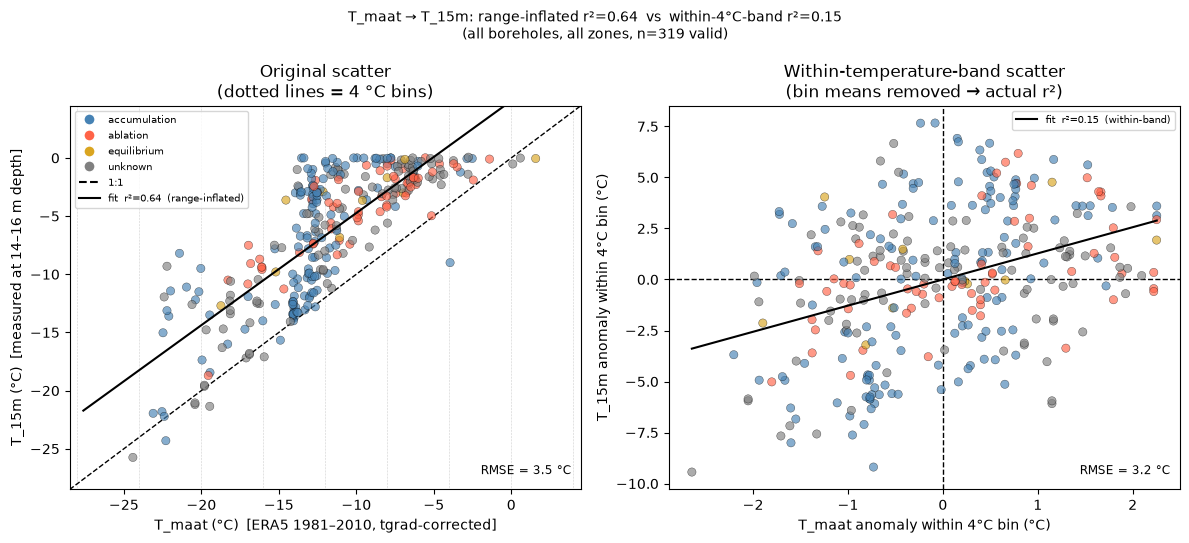


Conclusion: 64% of variance explained overall, but only 15% within a 4°C band.
Range-inflation factor: ×4.3


In [179]:
# ── Experiment: within-temperature-band R² ────────────────────────────────────
# The r²=0.64 above is inflated by the wide temperature range (−30 to 0 °C).
# Any two profiles-climate variables will correlate across such a span. The real
# question is: within a narrow T_maat window, how well does T_maat predict T_15m?
#
# Method: bin the data into BIN_WIDTH °C intervals along T_maat, subtract each
# bin's mean from both axes (removing the between-bin variance), then re-fit.
# The resulting r² reflects predictive skill *beyond* "polar regions are profiles".

BIN_WIDTH = 4  # °C

m15_exp = m15.copy()
bins = np.arange(
    np.floor(m15_exp['T_maat'].min() / BIN_WIDTH) * BIN_WIDTH,
    np.ceil(m15_exp['T_maat'].max()  / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH,
    BIN_WIDTH,
)
m15_exp['T_bin'] = pd.cut(m15_exp['T_maat'], bins=bins)

# Bin means for both axes
bin_means = (
    m15_exp.groupby('T_bin', observed=True)[['T_maat', 'temperature']]
    .mean()
    .rename(columns={'T_maat': 'Tmaat_mean', 'temperature': 'T15m_mean'})
)
m15_exp = m15_exp.join(bin_means, on='T_bin')

# Within-bin anomalies
m15_exp['Tmaat_anom'] = m15_exp['T_maat']      - m15_exp['Tmaat_mean']
m15_exp['T15m_anom']  = m15_exp['temperature'] - m15_exp['T15m_mean']

# Drop bins with < 5 members
valid_bins = m15_exp['T_bin'].value_counts()
valid_bins = valid_bins[valid_bins >= 5].index
m15_w = m15_exp[m15_exp['T_bin'].isin(valid_bins)].dropna(
    subset=['Tmaat_anom', 'T15m_anom'])

# ── Regressions ───────────────────────────────────────────────────────────────
sl_tot, ic_tot, r_tot, _, _ = stats.linregress(m15['T_maat'], m15['temperature'])
sl_w,   ic_w,   r_w,   _, _ = stats.linregress(m15_w['Tmaat_anom'], m15_w['T15m_anom'])

rmse_tot = np.sqrt(((m15['temperature'] - (ic_tot + sl_tot * m15['T_maat']))**2).mean())
rmse_w   = np.sqrt(((m15_w['T15m_anom']  - (ic_w   + sl_w   * m15_w['Tmaat_anom']))**2).mean())

# R² of the naive 1:1 line (T_15m = T_maat) for reference
ss_tot   = ((m15['temperature'] - m15['temperature'].mean())**2).sum()
ss_res11 = ((m15['temperature'] - m15['T_maat'])**2).sum()
r2_11    = 1 - ss_res11 / ss_tot

print(f'Original (range-inflated) r²  = {r_tot**2:.3f}   RMSE = {rmse_tot:.2f} °C  n = {len(m15)}')
print(f'1:1 line r²                    = {r2_11:.3f}')
print(f'Within-{BIN_WIDTH}°C-bin r²          = {r_w**2:.3f}   RMSE = {rmse_w:.2f} °C  n = {len(m15_w)}')

# ── Figure ─────────────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D
mba_cmap = {'accumulation': 'steelblue', 'ablation': 'tomato',
            'equilibrium': 'goldenrod'}
c_all = m15_exp['mass_balance_area'].map(mba_cmap).fillna('grey')
c_w   = m15_w  ['mass_balance_area'].map(mba_cmap).fillna('grey')

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

# Left — original scatter with bin boundaries
ax = axes[0]
ax.scatter(m15_exp['T_maat'], m15_exp['temperature'],
           c=c_all, alpha=0.65, edgecolors='k', linewidths=0.3, zorder=3)
for b in bins:
    ax.axvline(b, color='k', lw=0.4, ls=':', alpha=0.35)
lim = [bins[0]-0.5, bins[-1]+0.5]
ax.plot(lim, lim, 'k--', lw=1, zorder=2)
x_fit = np.linspace(m15['T_maat'].min(), m15['T_maat'].max(), 200)
ax.plot(x_fit, ic_tot + sl_tot*x_fit, 'k-', lw=1.5, zorder=4)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('T_maat (°C)  [ERA5 1981–2010, tgrad-corrected]')
ax.set_ylabel('T_15m (°C)  [measured at 14–16 m depth]')
ax.set_title(f'Original scatter\n(dotted lines = {BIN_WIDTH} °C bins)')
handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', label='accumulation', markersize=8),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',    label='ablation',     markersize=8),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='goldenrod', label='equilibrium',  markersize=8),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='grey',      label='unknown',      markersize=8),
    Line2D([0],[0], color='k', ls='--', label='1:1'),
    Line2D([0],[0], color='k', ls='-',  label=f'fit  r²={r_tot**2:.2f}  (range-inflated)'),
]
ax.legend(handles=handles, fontsize=7.5, loc='upper left')
ax.text(0.98, 0.04, f'RMSE = {rmse_tot:.1f} °C', transform=ax.transAxes,
        ha='right', fontsize=8.5, color='k')

# Right — within-bin anomalies
ax = axes[1]
ax.scatter(m15_w['Tmaat_anom'], m15_w['T15m_anom'],
           c=c_w, alpha=0.65, edgecolors='k', linewidths=0.3, zorder=3)
x_anom = np.linspace(m15_w['Tmaat_anom'].min(), m15_w['Tmaat_anom'].max(), 200)
ax.plot(x_anom, ic_w + sl_w*x_anom, 'k-', lw=1.5, zorder=4,
        label=f'fit  r²={r_w**2:.2f}  (within-band)')
ax.axhline(0, color='k', ls='--', lw=1, zorder=2)
ax.axvline(0, color='k', ls='--', lw=1, zorder=2)
ax.set_xlabel(f'T_maat anomaly within {BIN_WIDTH}°C bin (°C)')
ax.set_ylabel(f'T_15m anomaly within {BIN_WIDTH}°C bin (°C)')
ax.set_title(f'Within-temperature-band scatter\n(bin means removed → actual r²)')
ax.legend(fontsize=7.5)
ax.text(0.98, 0.04, f'RMSE = {rmse_w:.1f} °C', transform=ax.transAxes,
        ha='right', fontsize=8.5, color='k')

plt.suptitle(
    f'T_maat → T_15m: range-inflated r²={r_tot**2:.2f}  vs  within-{BIN_WIDTH}°C-band r²={r_w**2:.2f}\n'
    f'(all boreholes, all zones, n={len(m15_w)} valid)',
    fontsize=10,
)
plt.tight_layout()
plt.savefig('../figures/fig_00b_within_band_r2.pdf', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nConclusion: {r_tot**2*100:.0f}% of variance explained overall, '
      f'but only {r_w**2*100:.0f}% within a {BIN_WIDTH}°C band.')
print(f'Range-inflation factor: ×{r_tot**2/max(r_w**2,0.001):.1f}')


In [180]:
# ── Regime distribution (all zones, profiles sites) ──────────────────────────────
print('Cold sites by regime (all mass balance zones):')
regime_stats = (profiles.groupby('regime')['dT_firn']
                .agg(n='count', median='median', mean='mean', std='std')
                .sort_values('n', ascending=False))
print(regime_stats.round(2).to_string())
print()
print('Breakdown by regime × mass_balance_area:')
print(profiles.groupby(['regime', 'mass_balance_area'])['dT_firn'].count().to_string())
print()
print('Note: regimes with n < 5 will be excluded from regression.')

Cold sites by regime (all mass balance zones):
                        n  median  mean   std
regime                                       
Temperate / Maritime  143    3.52  4.05  3.08
Sub-Continental       114    6.65  6.94  1.66
Polar / High-Arctic   106    6.80  7.89  3.76

Breakdown by regime × mass_balance_area:
regime                mass_balance_area
Polar / High-Arctic   ablation              40
                      accumulation          63
                      equilibrium            3
Sub-Continental       ablation              51
                      accumulation          34
                      equilibrium           29
Temperate / Maritime  ablation              17
                      accumulation         124
                      equilibrium            2

Note: regimes with n < 5 will be excluded from regression.


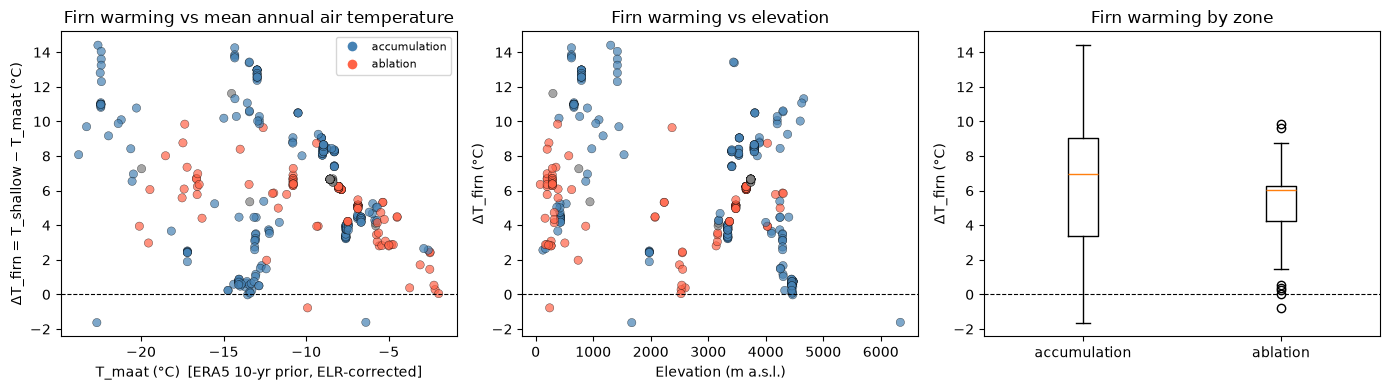

Saved: figures/fig_01_dT_firn_overview.pdf


In [181]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

colours = profiles['mass_balance_area'].map({'accumulation': 'steelblue', 'ablation': 'tomato'}).fillna('grey')
xlabel = f'T_maat (°C)  [ERA5 {LOOKBACK_YRS}-yr prior, ELR-corrected]'

# Plot 1: dT_firn vs T_maat
ax = axes[0]
ax.scatter(profiles['T_maat'], profiles['dT_firn'], c=colours, alpha=0.7, edgecolors='k', linewidths=0.3)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel(xlabel)
ax.set_ylabel('ΔT_firn = T_shallow − T_maat (°C)')
ax.set_title('Firn warming vs mean annual air temperature')

# Plot 2: dT_firn vs elevation
ax = axes[1]
ax.scatter(profiles['elevation'], profiles['dT_firn'], c=colours, alpha=0.7, edgecolors='k', linewidths=0.3)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Elevation (m a.s.l.)')
ax.set_ylabel('ΔT_firn (°C)')
ax.set_title('Firn warming vs elevation')

# Plot 3: dT_firn by mass_balance_area (boxplot)
ax = axes[2]
groups = [profiles[profiles['mass_balance_area'] == g]['dT_firn'].dropna().values
          for g in ['accumulation', 'ablation']]
ax.boxplot(groups, tick_labels=['accumulation', 'ablation'], notch=False)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_ylabel('ΔT_firn (°C)')
ax.set_title('Firn warming by zone')

from matplotlib.lines import Line2D
legend_handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', label='accumulation', markersize=8),
                  Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato', label='ablation', markersize=8)]
axes[0].legend(handles=legend_handles, fontsize=8)

plt.tight_layout()
plt.savefig('../figures/fig_01_dT_firn_overview.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig_01_dT_firn_overview.pdf')

Regime counts (all zones):
regime
Temperate / Maritime    143
Sub-Continental         114
Polar / High-Arctic     106



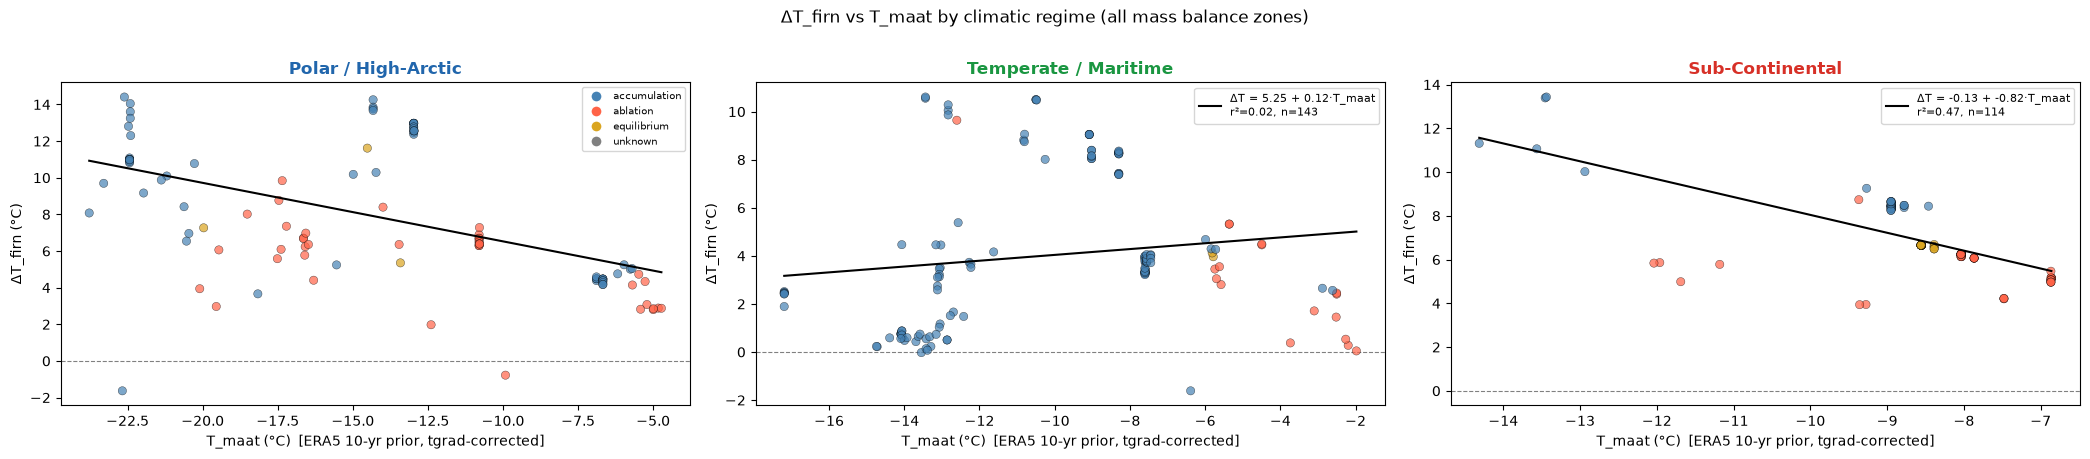

Saved: figures/fig_03_regime_regression.pdf

Regime                        n  median ΔT    slope  intercept      r²
--------------------------------------------------------------------
Polar / High-Arctic         106       6.80   -0.319      3.334   0.258
Temperate / Maritime        143       3.52    0.121      5.251   0.022
Sub-Continental             114       6.65   -0.817     -0.128   0.469


In [182]:
# ── Per-regime boxplot + regression: ΔT_firn vs T_maat (all zones) ───────────
from scipy import stats as _stats

REGIME_ORDER = ['Polar / High-Arctic', 'Temperate / Maritime', 'Sub-Continental']
REGIME_COLORS = {
    'Polar / High-Arctic':  '#2166ac',
    'Temperate / Maritime': '#1a9641',
    'Sub-Continental':      '#d73027',
}
MIN_N = 5

print('Regime counts (all zones):')
print(profiles['regime'].value_counts().to_string())
print()

results = []
for regime in REGIME_ORDER:
    sub = profiles[profiles['regime'] == regime].dropna(subset=['T_maat', 'dT_firn'])
    if len(sub) < MIN_N:
        print(f'  {regime}: n={len(sub)} — skipped (< {MIN_N})')
        continue
    sl, ic, r, p, se = _stats.linregress(sub['T_maat'], sub['dT_firn'])
    results.append(dict(regime=regime, n=len(sub), slope=sl, intercept=ic,
                        r2=r**2, p=p, median_dT=sub['dT_firn'].median()))

if not results:
    raise RuntimeError(
        "No regimes matched REGIME_ORDER. Re-run from cell-8 to propagate REGIME_MAP."
    )

# ── Facet scatter plot ────────────────────────────────────────────────────────
n_reg = len(results)
ncols = min(n_reg, 3)
nrows = (n_reg + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.5 * nrows), squeeze=False)
axes_flat = axes.ravel()

mba_colors = {'accumulation': 'steelblue', 'ablation': 'tomato',
              'equilibrium': 'goldenrod'}
xlabel = f'T_maat (°C)  [ERA5 {LOOKBACK_YRS}-yr prior, tgrad-corrected]'

for ax, res in zip(axes_flat, results):
    regime = res['regime']
    sub = profiles[profiles['regime'] == regime].dropna(subset=['T_maat', 'dT_firn'])
    pt_colors = sub['mass_balance_area'].map(mba_colors).fillna('grey')

    ax.scatter(sub['T_maat'], sub['dT_firn'], c=pt_colors, alpha=0.7,
               edgecolors='k', linewidths=0.3, zorder=3)
    x_fit = np.linspace(sub['T_maat'].min(), sub['T_maat'].max(), 100)
    ax.plot(x_fit, res['intercept'] + res['slope'] * x_fit,
            color='k', lw=1.5, zorder=4,
            label=f"ΔT = {res['intercept']:.2f} + {res['slope']:.2f}·T_maat\nr²={res['r2']:.2f}, n={res['n']}")
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_title(regime, fontweight='bold', color=REGIME_COLORS[regime])
    ax.set_xlabel(xlabel)
    ax.set_ylabel('ΔT_firn (°C)')
    ax.legend(fontsize=8)

for ax in axes_flat[len(results):]:
    ax.set_visible(False)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', label='accumulation', markersize=8),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',    label='ablation',     markersize=8),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='goldenrod', label='equilibrium',  markersize=8),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='grey',      label='unknown',      markersize=8),
]
axes_flat[0].legend(handles=legend_handles, fontsize=7, loc='upper right')

plt.suptitle('ΔT_firn vs T_maat by climatic regime (all mass balance zones)', y=1.01)
plt.tight_layout()
plt.savefig('../figures/fig_03_regime_regression.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig_03_regime_regression.pdf')

# ── Summary table ─────────────────────────────────────────────────────────────
print()
print(f'{"Regime":<25}  {"n":>4}  {"median ΔT":>9}  {"slope":>7}  {"intercept":>9}  {"r²":>6}')
print('-' * 68)
for res in results:
    print(f"{res['regime']:<25}  {res['n']:>4}  {res['median_dT']:>9.2f}  "
          f"{res['slope']:>7.3f}  {res['intercept']:>9.3f}  {res['r2']:>6.3f}")

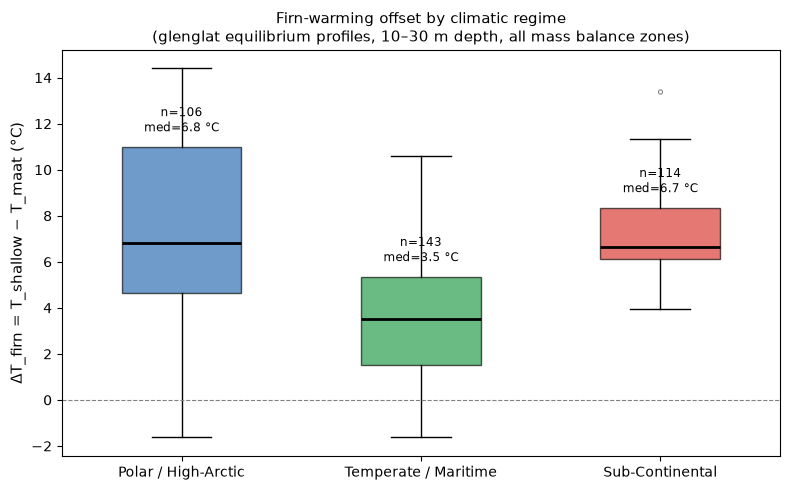

Saved: figures/fig_03_regime_boxplot.pdf

Regime                        n    mean     std     p25     med     p75     min     max
-----------------------------------------------------------------------------------
Polar / High-Arctic         106    7.89    3.74    4.62    6.80   10.99   -1.63   14.41
Temperate / Maritime        143    4.05    3.07    1.50    3.52    5.35   -1.61   10.61
Sub-Continental             114    6.94    1.65    6.14    6.65    8.35    3.94   13.43


In [183]:
# ── Regime boxplot — calibration target for GloGEMflow ───────────────────────
REGIME_ORDER = ['Polar / High-Arctic', 'Temperate / Maritime', 'Sub-Continental']
REGIME_COLORS = {
    'Polar / High-Arctic':  '#2166ac',
    'Temperate / Maritime': '#1a9641',
    'Sub-Continental':      '#d73027',
}

data_by_regime = {r: profiles[profiles['regime'] == r]['dT_firn'].dropna().values
                  for r in REGIME_ORDER}
labels_plot = [r for r in REGIME_ORDER if len(data_by_regime[r]) >= 5]
data_plot    = [data_by_regime[r] for r in labels_plot]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(data_plot, tick_labels=labels_plot, patch_artist=True,
                medianprops=dict(color='k', lw=2), widths=0.5,
                flierprops=dict(marker='o', markersize=3, alpha=0.4,
                                markeredgewidth=0.5))
for patch, lbl in zip(bp['boxes'], labels_plot):
    patch.set_facecolor(REGIME_COLORS[lbl])
    patch.set_alpha(0.65)

for i, (lbl, d) in enumerate(zip(labels_plot, data_plot), start=1):
    ax.text(i, np.percentile(d, 75) + 0.5,
            f'n={len(d)}\nmed={np.median(d):.1f} °C',
            ha='center', va='bottom', fontsize=8.5)

ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_ylabel('ΔT_firn = T_shallow − T_maat (°C)', fontsize=11)
ax.set_title('Firn-warming offset by climatic regime\n'
             '(glenglat equilibrium profiles, 10–30 m depth, all mass balance zones)',
             fontsize=11)
ax.tick_params(axis='x', labelsize=10)
plt.tight_layout()
plt.savefig('../figures/fig_03_regime_boxplot.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig_03_regime_boxplot.pdf')

# ── Uncertainty statistics table ──────────────────────────────────────────────
print()
print(f'{"Regime":<25}  {"n":>4}  {"mean":>6}  {"std":>6}  {"p25":>6}  {"med":>6}  {"p75":>6}  {"min":>6}  {"max":>6}')
print('-' * 83)
for lbl, d in zip(labels_plot, data_plot):
    print(f'{lbl:<25}  {len(d):>4}  {np.mean(d):>6.2f}  {np.std(d):>6.2f}  '
          f'{np.percentile(d,25):>6.2f}  {np.median(d):>6.2f}  {np.percentile(d,75):>6.2f}  '
          f'{d.min():>6.2f}  {d.max():>6.2f}')

Region                   n  median ΔT    slope  intercept      r²        p
------------------------------------------------------------------------
Svalbard                30       4.47   -1.074     -2.332   0.942   0.0000
CentralAsia            114       6.65   -0.817     -0.128   0.469   0.0000
ArcticCanadaN           41       7.27   -0.541     -2.280   0.260   0.0007
RussianArctic           34      10.99   -0.197      7.268   0.132   0.0350
SouthernAndes            9       2.45   -0.057      1.245   0.079   0.4642
CentralEurope          129       3.66    0.142      5.526   0.023   0.0853


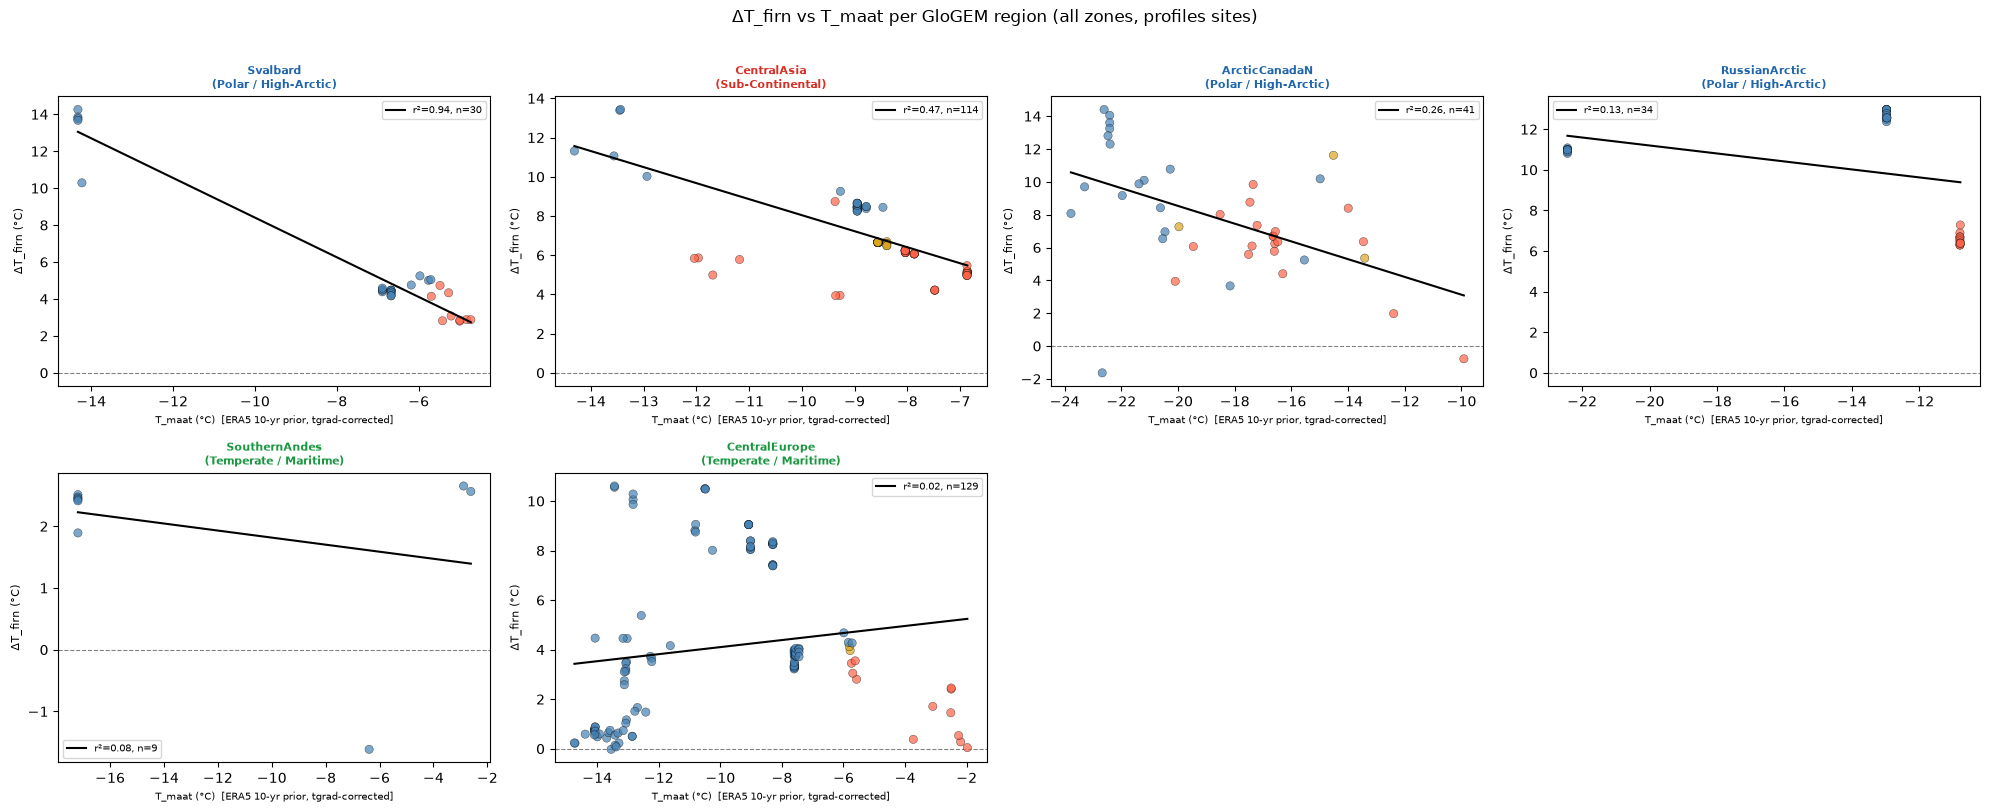

Saved: figures/fig_04_region_regression.pdf


In [184]:
# ── Per-GloGEM-region regression: ΔT_firn vs T_maat (all zones) ──────────────
from scipy import stats as _stats

region_results = []
for reg in sorted(profiles['glogem_region'].dropna().unique()):
    sub = profiles[profiles['glogem_region'] == reg].dropna(subset=['T_maat', 'dT_firn'])
    if len(sub) < 5:
        continue
    sl, ic, r, p, se = _stats.linregress(sub['T_maat'], sub['dT_firn'])
    region_results.append(dict(region=reg, n=len(sub), slope=sl, intercept=ic,
                               r2=r**2, p=p, median_dT=sub['dT_firn'].median()))

region_results.sort(key=lambda x: -x['r2'])

print(f'{"Region":<20}  {"n":>4}  {"median ΔT":>9}  {"slope":>7}  {"intercept":>9}  {"r²":>6}  {"p":>7}')
print('-' * 72)
for res in region_results:
    print(f"{res['region']:<20}  {res['n']:>4}  {res['median_dT']:>9.2f}  "
          f"{res['slope']:>7.3f}  {res['intercept']:>9.3f}  {res['r2']:>6.3f}  {res['p']:>7.4f}")

# ── Facet scatter plot ────────────────────────────────────────────────────────
n_reg = len(region_results)
ncols = 4
nrows = (n_reg + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
axes_flat = axes.ravel()

mba_colors = {'accumulation': 'steelblue', 'ablation': 'tomato', 'equilibrium': 'goldenrod'}
xlabel = f'T_maat (°C)  [ERA5 {LOOKBACK_YRS}-yr prior, tgrad-corrected]'

for ax, res in zip(axes_flat, region_results):
    reg = res['region']
    sub = profiles[profiles['glogem_region'] == reg].dropna(subset=['T_maat', 'dT_firn'])
    regime = REGIME_MAP.get(reg, 'Other')
    pt_colors = sub['mass_balance_area'].map(mba_colors).fillna('grey')

    ax.scatter(sub['T_maat'], sub['dT_firn'], c=pt_colors, alpha=0.7,
               edgecolors='k', linewidths=0.3, zorder=3)
    x_fit = np.linspace(sub['T_maat'].min(), sub['T_maat'].max(), 100)
    ax.plot(x_fit, res['intercept'] + res['slope'] * x_fit, 'k-', lw=1.5, zorder=4,
            label=f"r²={res['r2']:.2f}, n={res['n']}")
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_title(f"{reg}\n({regime})", fontsize=8, fontweight='bold',
                 color=REGIME_COLORS.get(regime, 'k'))
    ax.set_xlabel(xlabel, fontsize=7)
    ax.set_ylabel('ΔT_firn (°C)', fontsize=8)
    ax.legend(fontsize=7)

for ax in axes_flat[len(region_results):]:
    ax.set_visible(False)

plt.suptitle('ΔT_firn vs T_maat per GloGEM region (all zones, profiles sites)', y=1.01)
plt.tight_layout()
plt.savefig('../figures/fig_04_region_regression.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig_04_region_regression.pdf')

Elevation correction (borehole − ERA5 cell, m) by regime:
                      count    mean    std     min     25%     50%     75%     max
regime                                                                            
Polar / High-Arctic   106.0   112.0  339.0  -649.0   -55.0   221.0   288.0   732.0
Sub-Continental       114.0   894.0  385.0 -1168.0   955.0   963.0  1035.0  1095.0
Temperate / Maritime  143.0  1415.0  678.0  -241.0  1062.0  1283.0  2045.0  2904.0

tgrad values (K/m) by regime — standard ELR is -0.0065 K/m:
                      count     mean      std      min      25%      50%      75%      max
regime                                                                                    
Polar / High-Arctic   106.0 -0.00474  0.00025 -0.00505 -0.00496 -0.00482 -0.00469 -0.00413
Sub-Continental       114.0 -0.00648  0.00009 -0.00651 -0.00651 -0.00651 -0.00651 -0.00611
Temperate / Maritime  143.0 -0.00602  0.00006 -0.00606 -0.00605 -0.00605 -0.00601 -0.00555

T_maat dif

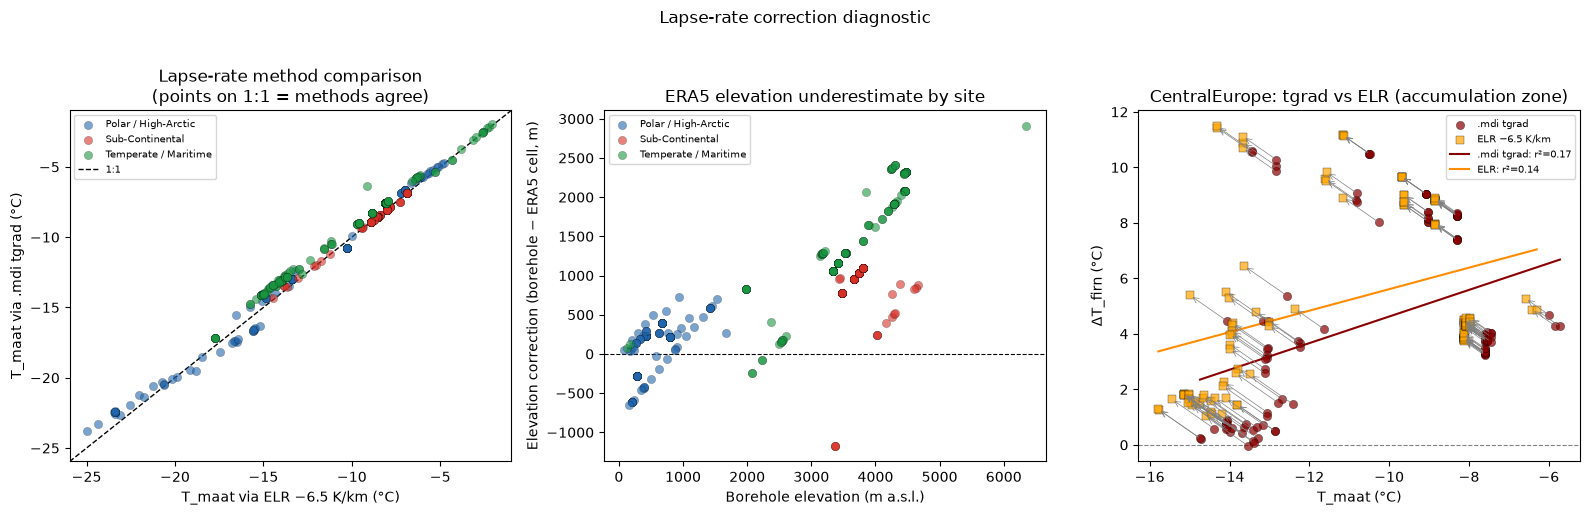

Saved: figures/fig_05_lapserate_diagnostic.pdf


In [185]:
# ── Diagnostic: does the lapse-rate correction bias T_maat? ──────────────────
# Re-compute T_maat using standard free-air ELR (-6.5 K/km) instead of .mdi tgrad.
# Large divergence between the two estimates flags regions where tgrad may be wrong.

ELR_STD = -0.0065  # K/m, standard environmental lapse rate

def era5_tmaat_elr(lat, lon, elev, year=None):
    """T_maat at borehole elevation using standard ELR (-6.5 K/km)."""
    if np.isnan(lat) or np.isnan(lon) or np.isnan(elev):
        return np.nan
    ilat = int(np.argmin(np.abs(era5_lat - lat)))
    ilon = int(np.argmin(np.abs(era5_lon - (lon % 360))))
    ann_yrs, ann_t = _load_point(ilat, ilon)
    if year is not None:
        mask = (ann_yrs >= year - LOOKBACK_YRS) & (ann_yrs <= year - 1)
        t_grid = ann_t[mask].mean() if mask.sum() >= 5 else ann_t[
            (ann_yrs >= REF_YEARS[0]) & (ann_yrs <= REF_YEARS[1])].mean()
    else:
        t_grid = ann_t[(ann_yrs >= REF_YEARS[0]) & (ann_yrs <= REF_YEARS[1])].mean()
    return t_grid + ELR_STD * (elev - era5_hgt[ilat, ilon])

def _profile_year(date_str):
    try:
        return int(str(date_str)[:4])
    except (ValueError, TypeError):
        return None

# Compute ELR-based T_maat and dT_firn for all paired profiles
paired['T_maat_elr'] = [
    era5_tmaat_elr(row.latitude, row.longitude, row.elevation,
                   year=_profile_year(row.profile_date_min))
    for _, row in paired.iterrows()
]
paired['dT_firn_elr'] = paired['T_shallow'] - paired['T_maat_elr']

# Elevation correction info for diagnostics
paired['era5_elev'] = [
    era5_hgt[int(np.argmin(np.abs(era5_lat - row.latitude))),
             int(np.argmin(np.abs(era5_lon - (row.longitude % 360))))]
    for _, row in paired.iterrows()
]
paired['elev_diff']    = paired['elevation'] - paired['era5_elev']
paired['tgrad_used']   = [_nearest_tgrad(r.latitude, r.longitude) for _, r in paired.iterrows()]
paired['T_maat_delta'] = paired['T_maat'] - paired['T_maat_elr']   # tgrad − ELR correction

print('Elevation correction (borehole − ERA5 cell, m) by regime:')
print(paired.groupby('regime')['elev_diff'].describe().round(0).to_string())
print()
print('tgrad values (K/m) by regime — standard ELR is -0.0065 K/m:')
print(paired.groupby('regime')['tgrad_used'].describe().round(5).to_string())
print()
print('T_maat difference tgrad−ELR (°C) by regime — positive = tgrad gives warmer T_maat:')
print(paired.groupby('regime')['T_maat_delta'].describe().round(2).to_string())

# ── Plot 1: tgrad vs ELR T_maat comparison scatter ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
for regime, grp in paired.groupby('regime'):
    col = REGIME_COLORS.get(regime, 'grey')
    ax.scatter(grp['T_maat_elr'], grp['T_maat'], color=col, alpha=0.6,
               edgecolors='k', linewidths=0.2, label=regime, zorder=3)
lim = [min(paired['T_maat_elr'].min(), paired['T_maat'].min()) - 1,
       max(paired['T_maat_elr'].max(), paired['T_maat'].max()) + 1]
ax.plot(lim, lim, 'k--', lw=1, label='1:1')
ax.set_xlabel('T_maat via ELR −6.5 K/km (°C)')
ax.set_ylabel('T_maat via .mdi tgrad (°C)')
ax.set_title('Lapse-rate method comparison\n(points on 1:1 = methods agree)')
ax.legend(fontsize=7, loc='upper left')
ax.set_xlim(lim); ax.set_ylim(lim)

# ── Plot 2: elevation correction magnitude by site ────────────────────────────
ax = axes[1]
for regime, grp in paired.groupby('regime'):
    col = REGIME_COLORS.get(regime, 'grey')
    ax.scatter(grp['elevation'], grp['elev_diff'], color=col, alpha=0.6,
               edgecolors='k', linewidths=0.2, label=regime, zorder=3)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Borehole elevation (m a.s.l.)')
ax.set_ylabel('Elevation correction (borehole − ERA5 cell, m)')
ax.set_title('ERA5 elevation underestimate by site')
ax.legend(fontsize=7)

# ── Plot 3: CentralEurope ΔT_firn — both lapse-rate methods ──────────────────
ax = axes[2]
from scipy import stats as _stats

ce = paired[
    (paired['glogem_region'] == 'CentralEurope') &
    (paired['mass_balance_area'] == 'accumulation')
].dropna(subset=['T_maat', 'T_maat_elr', 'dT_firn', 'dT_firn_elr'])

ax.scatter(ce['T_maat'],     ce['dT_firn'],     color='darkred',   alpha=0.7,
           edgecolors='k', linewidths=0.3, label='.mdi tgrad', zorder=3)
ax.scatter(ce['T_maat_elr'], ce['dT_firn_elr'], color='orange', alpha=0.7,
           edgecolors='k', linewidths=0.3, marker='s', label='ELR −6.5 K/km', zorder=3)

# Arrows showing how each point shifts when switching to ELR
for _, r in ce.iterrows():
    ax.annotate('', xy=(r['T_maat_elr'], r['dT_firn_elr']),
                xytext=(r['T_maat'], r['dT_firn']),
                arrowprops=dict(arrowstyle='->', color='grey', lw=0.5))

for vals, col, lbl in [
    (ce[['T_maat',     'dT_firn']].values,     'darkred',    '.mdi tgrad'),
    (ce[['T_maat_elr', 'dT_firn_elr']].values, 'darkorange', 'ELR'),
]:
    sl, ic, r, _, _ = _stats.linregress(vals[:, 0], vals[:, 1])
    x_fit = np.linspace(vals[:, 0].min(), vals[:, 0].max(), 100)
    ax.plot(x_fit, ic + sl * x_fit, color=col, lw=1.5,
            label=f'{lbl}: r²={r**2:.2f}')

ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel('T_maat (°C)')
ax.set_ylabel('ΔT_firn (°C)')
ax.set_title('CentralEurope: tgrad vs ELR (accumulation zone)')
ax.legend(fontsize=7)

plt.suptitle('Lapse-rate correction diagnostic', y=1.02)
plt.tight_layout()
plt.savefig('../figures/fig_05_lapserate_diagnostic.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig_05_lapserate_diagnostic.pdf')

Accumulation-zone profiles sites for regression: 221

Regression: ΔT_firn = 3.751 + -0.224 · T_maat
  r² = 0.070,  p = 0.0001,  SE(slope) = 0.0552


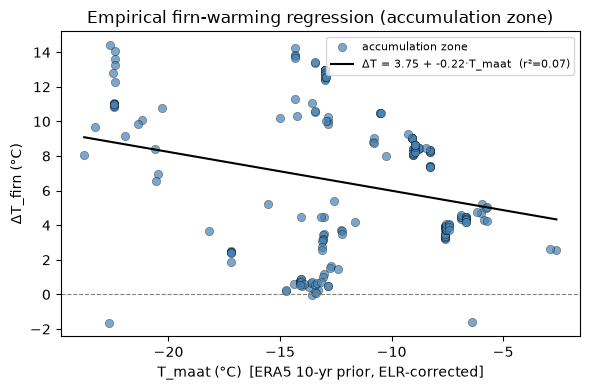

Saved: figures/fig_02_regression.pdf


In [186]:
acc = profiles[profiles['mass_balance_area'] == 'accumulation'].dropna(subset=['dT_firn', 'T_maat'])
print(f'Accumulation-zone profiles sites for regression: {len(acc)}')

# Linear regression: dT_firn = a + b * T_maat
slope, intercept, r, p, se = stats.linregress(acc['T_maat'], acc['dT_firn'])
print(f'\nRegression: ΔT_firn = {intercept:.3f} + {slope:.3f} · T_maat')
print(f'  r² = {r**2:.3f},  p = {p:.4f},  SE(slope) = {se:.4f}')

x_fit = np.linspace(acc['T_maat'].min(), acc['T_maat'].max(), 100)
y_fit = intercept + slope * x_fit

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(acc['T_maat'], acc['dT_firn'], color='steelblue', alpha=0.7,
           edgecolors='k', linewidths=0.3, label='accumulation zone')
ax.plot(x_fit, y_fit, color='k', lw=1.5,
        label=f'ΔT = {intercept:.2f} + {slope:.2f}·T_maat  (r²={r**2:.2f})')
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel(f'T_maat (°C)  [ERA5 {LOOKBACK_YRS}-yr prior, ELR-corrected]')
ax.set_ylabel('ΔT_firn (°C)')
ax.set_title('Empirical firn-warming regression (accumulation zone)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../figures/fig_02_regression.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig_02_regression.pdf')

## Section 5 — Compare with Cuffey & Paterson analytical formula

Cuffey & Paterson (2010, Eq. 9.29):
$$\Delta T_{firn} = \frac{L_f \, \dot{m}_{rf}}{\rho_i \, c_i \, \bar{u}}$$
where:
- $L_f = 334{,}000$ J kg⁻¹ (latent heat of fusion)
- $\dot{m}_{rf}$ = annual refreezing rate (m w.e. yr⁻¹)
- $\rho_i = 900$ kg m⁻³, $c_i = 2009$ J kg⁻¹ K⁻¹
- $\bar{u}$ = mean vertical velocity of firn through the temperature signal propagation depth (≈ accumulation rate)

A simpler working form (for a quick first-order estimate) when refreezing ≈ some fraction of accumulation:
$$\Delta T_{firn} \approx \frac{L_f}{c_i} \cdot f_{rf}$$
where $f_{rf}$ is the fraction of annual accumulation that refreezes (dimensionless, typically 0.05–0.3 for cold Alpine glaciers).  
This gives: ΔT_firn ≈ 166 °C · f_rf  →  for f_rf = 0.03 → ΔT ≈ 5 °C.

**Note**: We do not have per-site accumulation/refreezing rates in glenglat.  
This section demonstrates the formula structure and expected magnitudes.  
Once GloGEM's own simulated refreezing per band is available, we can apply the formula self-consistently.

Implied refreezing fraction at T_deep = 0 °C: f_rf = 0.0226
  → 2.3% of accumulation refreezes in the firn column


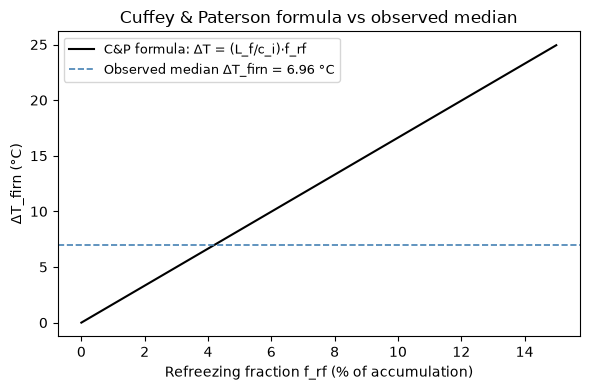

Saved: fig_03_CP_formula.pdf


In [187]:
# Physical constants
Lf = 334_000.0   # J/kg
ci = 2009.0      # J/(kg·K)
rho_i = 900.0    # kg/m³

# Derive implied refreezing fraction from the regression:
# ΔT_firn = Lf/ci * f_rf   →   f_rf = ΔT_firn * ci / Lf
# Use the intercept of the regression (value at T_deep = 0 °C as a reference)
dT_ref = intercept  # from regression at T_deep = 0
f_rf_implied = dT_ref * ci / Lf
print(f'Implied refreezing fraction at T_deep = 0 °C: f_rf = {f_rf_implied:.4f}')
print(f'  → {f_rf_implied*100:.1f}% of accumulation refreezes in the firn column')

# Plot: predicted ΔT_firn from C&P formula across a range of refreezing fractions
f_range = np.linspace(0, 0.15, 200)
dT_CP = Lf / ci * f_range

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(f_range * 100, dT_CP, color='k', lw=1.5, label='C&P formula: ΔT = (L_f/c_i)·f_rf')
ax.axhline(float(acc['dT_firn'].median()), color='steelblue', lw=1.2, ls='--',
           label=f'Observed median ΔT_firn = {float(acc["dT_firn"].median()):.2f} °C')
ax.set_xlabel('Refreezing fraction f_rf (% of accumulation)')
ax.set_ylabel('ΔT_firn (°C)')
ax.set_title('Cuffey & Paterson formula vs observed median')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_03_CP_formula.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_03_CP_formula.pdf')

## Section 6 — Final derived relationship and summary

In [188]:
# Summary statistics for the accumulation-zone firn warming
print('Accumulation-zone ΔT_firn statistics (profiles sites, T_deep ≤ {:.0f} °C):'.format(TMEAN_MAX))
print(acc['dT_firn'].describe().round(3))
print()
print('Regression: ΔT_firn = {:.3f} + {:.3f} · T_deep_background'.format(intercept, slope))
print('  Interpretation: for each 1 °C colder T_mean, ΔT_firn changes by {:.3f} °C'.format(slope))
print()
print('C&P formula: ΔT_firn = (L_f / c_i) · f_rf = {:.1f} · f_rf'.format(Lf/ci))
print('  Implied f_rf from regression intercept: {:.4f} ({:.1f}%)'.format(f_rf_implied, f_rf_implied*100))

Accumulation-zone ΔT_firn statistics (profiles sites, T_deep ≤ -1 °C):
count    221.000
mean       6.412
std        4.048
min       -1.631
25%        3.351
50%        6.959
75%        9.056
max       14.406
Name: dT_firn, dtype: float64

Regression: ΔT_firn = 3.751 + -0.224 · T_deep_background
  Interpretation: for each 1 °C colder T_mean, ΔT_firn changes by -0.224 °C

C&P formula: ΔT_firn = (L_f / c_i) · f_rf = 166.3 · f_rf
  Implied f_rf from regression intercept: 0.0226 (2.3%)


In [189]:
import json

# Export parameters for use in IDL implementation
params = {
    'regression': {
        'intercept': float(round(intercept, 4)),
        'slope': float(round(slope, 4)),
        'r2': float(round(r**2, 4)),
        'n_sites': int(len(acc)),
        'description': 'delta_T_firn = intercept + slope * T_deep_background',
        'units': 'degC'
    },
    'cp_formula': {
        'Lf_J_per_kg': Lf,
        'ci_J_per_kg_K': ci,
        'implied_f_rf': float(round(f_rf_implied, 4)),
        'description': 'delta_T_firn = (Lf / ci) * f_rf, where f_rf is refreezing fraction'
    },
    'accumulation_zone_stats': {
        'median_dT': float(round(float(acc['dT_firn'].median()), 3)),
        'mean_dT': float(round(float(acc['dT_firn'].mean()), 3)),
        'std_dT': float(round(float(acc['dT_firn'].std()), 3)),
    }
}

with open('firn_warming_params.json', 'w') as f:
    json.dump(params, f, indent=2)

print('Exported: firn_warming_params.json')
print(json.dumps(params, indent=2))

Exported: firn_warming_params.json
{
  "regression": {
    "intercept": 3.7505,
    "slope": -0.2244,
    "r2": 0.0701,
    "n_sites": 221,
    "description": "delta_T_firn = intercept + slope * T_deep_background",
    "units": "degC"
  },
  "cp_formula": {
    "Lf_J_per_kg": 334000.0,
    "ci_J_per_kg_K": 2009.0,
    "implied_f_rf": 0.0226,
    "description": "delta_T_firn = (Lf / ci) * f_rf, where f_rf is refreezing fraction"
  },
  "accumulation_zone_stats": {
    "median_dT": 6.959,
    "mean_dT": 6.412,
    "std_dT": 4.048
  }
}


In [190]:
# --- Written summary ---
print("""
SUMMARY
=======
We extracted englacial temperature measurements from the glenglat database at 10–30 m depth
(seasonal wave attenuated), filtering for equilibrium profiles and profiles sites (T_deep ≤ -1 °C).
The firn-warming offset ΔT_firn = T_shallow − T_deep was computed per profile as a proxy for the
latent-heat warming contribution above the seasonal zero-amplitude depth.

Key findings:
- Accumulation-zone sites show a clear positive ΔT_firn (firn warmer than deep ice), as expected
  from latent heat of refreezing.
- Ablation-zone sites show ΔT_firn ≈ 0 or slightly negative (no firn, no refreezing).
- The linear regression for accumulation-zone sites gives: ΔT_firn = {:.2f} + {:.2f} · T_deep
  (r² = {:.2f}, n = {}).
- The Cuffey & Paterson formula implies an effective refreezing fraction of {:.1f}%, which is
  physically plausible for profiles Alpine accumulation zones.

Recommended implementation in GloGEMflow (initialise_firnicetemp_spinup.pro):
- Use GloGEM's own simulated refreezing fraction per elevation band (1961-1990 mean) and apply
  the C&P formula: delta_T_firn = (Lf / ci) * f_rf_band.
- Calibrate / validate against the regression derived here.
- Apply this correction to construct a physically-shaped initial depth profile (surface = T_mean,
  15 m = T_mean + delta_T_firn, deeper layers converge to T_mean + delta_T_firn).
- Then run 3-5 cyclic 1961-1990 passes for deep-layer thermal equilibration.
""".format(intercept, slope, r**2, len(acc), f_rf_implied*100))


SUMMARY
We extracted englacial temperature measurements from the glenglat database at 10–30 m depth
(seasonal wave attenuated), filtering for equilibrium profiles and profiles sites (T_deep ≤ -1 °C).
The firn-warming offset ΔT_firn = T_shallow − T_deep was computed per profile as a proxy for the
latent-heat warming contribution above the seasonal zero-amplitude depth.

Key findings:
- Accumulation-zone sites show a clear positive ΔT_firn (firn warmer than deep ice), as expected
  from latent heat of refreezing.
- Ablation-zone sites show ΔT_firn ≈ 0 or slightly negative (no firn, no refreezing).
- The linear regression for accumulation-zone sites gives: ΔT_firn = 3.75 + -0.22 · T_deep
  (r² = 0.07, n = 221).
- The Cuffey & Paterson formula implies an effective refreezing fraction of 2.3%, which is
  physically plausible for profiles Alpine accumulation zones.

Recommended implementation in GloGEMflow (initialise_firnicetemp_spinup.pro):
- Use GloGEM's own simulated refreezing fraction

## Section 7 — Alternative climate predictors for ΔT_firn

MAAT conflates two physically distinct processes:
- **Summer warmth** → more melt → more liquid water available for refreezing (raises ΔT_firn)
- **Winter cold** → larger cold content → more refreezing capacity for that melt (raises ΔT_firn)

Separating these into distinct metrics may improve predictive skill and provide a better basis
for the GloGEM initialization lookup table.

| Predictor | Physical meaning | Expected sign |
|-----------|-----------------|---------------|
| **PDD** (°C·d > 0°C) | Melt-water supply; more melt = more potential refreeze | + |
| **NDD** (°C·d < 0°C) | Snowpack cold content; colder winters = more refreezing capacity | + |
| **NDD_ratio** = NDD/(PDD+NDD) | Dimensionless refreeze potential (0 = all warmth, 1 = all cold) | + |
| **T_amplitude** = T_max − T_min | Seasonal range; separates continental from maritime regimes | + |

All metrics use the ERA5 1981–2010 reference climatology with the same tgrad lapse-rate correction
applied to T_maat in earlier sections.

In [191]:
# ── Monthly climate variables from ERA5 (10-year prior to borehole) ─────────
# PDD:         Σ max(T_month, 0) × days — melt-water supply proxy
# NDD:         Σ max(-T_month, 0) × days — snowpack profiles-content proxy
# NDD_ratio:   NDD / (PDD + NDD) — dimensionless refreezing potential (0=warm, 1=profiles)
# T_amplitude: max(monthly T) − min(monthly T) — continental vs maritime index
#
# Reference period: 30 years prior to borehole measurement date (consistent with
# era5_tmaat LOOKBACK_YRS=30). Boreholes before 1970 excluded (< 30 yrs ERA5 data).

_era5_month    = era5_time.astype('datetime64[M]').astype(int) % 12 + 1
DAYS_PER_MONTH = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
_monthly_raw   = {}   # (ilat, ilon) → full monthly T series in °C

def _monthly_series(ilat, ilon):
    """Cache the full monthly ERA5 time series (°C) for a grid cell."""
    key = (ilat, ilon)
    if key not in _monthly_raw:
        _monthly_raw[key] = ds_t['t2m'].isel(latitude=ilat, longitude=ilon).values - 273.15
    return _monthly_raw[key]

def _monthly_clim(ilat, ilon, year_from, year_to):
    """Mean monthly climatology over [year_from, year_to] at grid cell."""
    ts_C  = _monthly_series(ilat, ilon)
    mask  = (era5_year >= year_from) & (era5_year <= year_to)
    ts_s  = ts_C[mask]
    m_s   = _era5_month[mask]
    if mask.sum() < 12:   # fallback to REF_YEARS if window too short
        mask  = (era5_year >= REF_YEARS[0]) & (era5_year <= REF_YEARS[1])
        ts_s  = ts_C[mask]
        m_s   = _era5_month[mask]
    return np.array([ts_s[m_s == m].mean() for m in range(1, 13)])

def era5_pdd_vars(lat, lon, elev, year=None):
    """PDD, NDD, NDD_ratio, T_amplitude at borehole elevation.
    year: measurement year; uses year-30 to year-1 window. Falls back to REF_YEARS.
    """
    if np.isnan(lat) or np.isnan(lon) or np.isnan(elev):
        return (np.nan,) * 4
    ilat = int(np.argmin(np.abs(era5_lat - lat)))
    ilon = int(np.argmin(np.abs(era5_lon - (lon % 360))))
    if year is not None:
        clim = _monthly_clim(ilat, ilon, year - LOOKBACK_YRS, year - 1)
    else:
        clim = _monthly_clim(ilat, ilon, REF_YEARS[0], REF_YEARS[1])
    clim  = clim.copy()
    tg_mon    = _nearest_tgrad_monthly(lat, lon)   # 12 monthly lapse rates
    elev_diff = elev - era5_hgt[ilat, ilon]
    clim     += tg_mon * elev_diff                 # element-wise per month
    PDD       = float(np.sum(np.maximum(clim, 0) * DAYS_PER_MONTH))
    NDD       = float(np.sum(np.maximum(-clim, 0) * DAYS_PER_MONTH))
    ratio     = NDD / (PDD + NDD) if (PDD + NDD) > 0 else np.nan
    amplitude = float(clim.max() - clim.min())
    return PDD, NDD, ratio, amplitude

def _profile_year(date_str):
    try:
        return int(str(date_str)[:4])
    except (ValueError, TypeError):
        return None

# Compute for every borehole in profiles — pass measurement year for 30-yr prior window
pdd_data = []
for _, row in profiles.iterrows():
    meas_year = _profile_year(row['profile_date_min'])
    pdd_data.append(era5_pdd_vars(row['latitude'], row['longitude'],
                                  row['elevation'], year=meas_year))

profiles[['PDD', 'NDD', 'NDD_ratio', 'T_amplitude']] = pdd_data
n_ok = profiles['PDD'].notna().sum()
print(f'Added PDD/NDD/NDD_ratio/T_amplitude for {n_ok} boreholes '
      f'({len(profiles)-n_ok} skipped)')
print()
print(profiles[['PDD', 'NDD', 'NDD_ratio', 'T_amplitude']].describe().round(1).to_string())


Added PDD/NDD/NDD_ratio/T_amplitude for 363 boreholes (0 skipped)

         PDD     NDD  NDD_ratio  T_amplitude
count  363.0   363.0      363.0        363.0
mean   158.1  4070.3        1.0         23.4
std    171.9  1581.9        0.1          4.9
min      0.0   986.7        0.6          6.8
25%      0.0  2913.0        0.9         19.9
50%    121.0  3457.2        1.0         24.4
75%    266.7  4839.1        1.0         25.5
max    883.1  8648.7        1.0         36.0


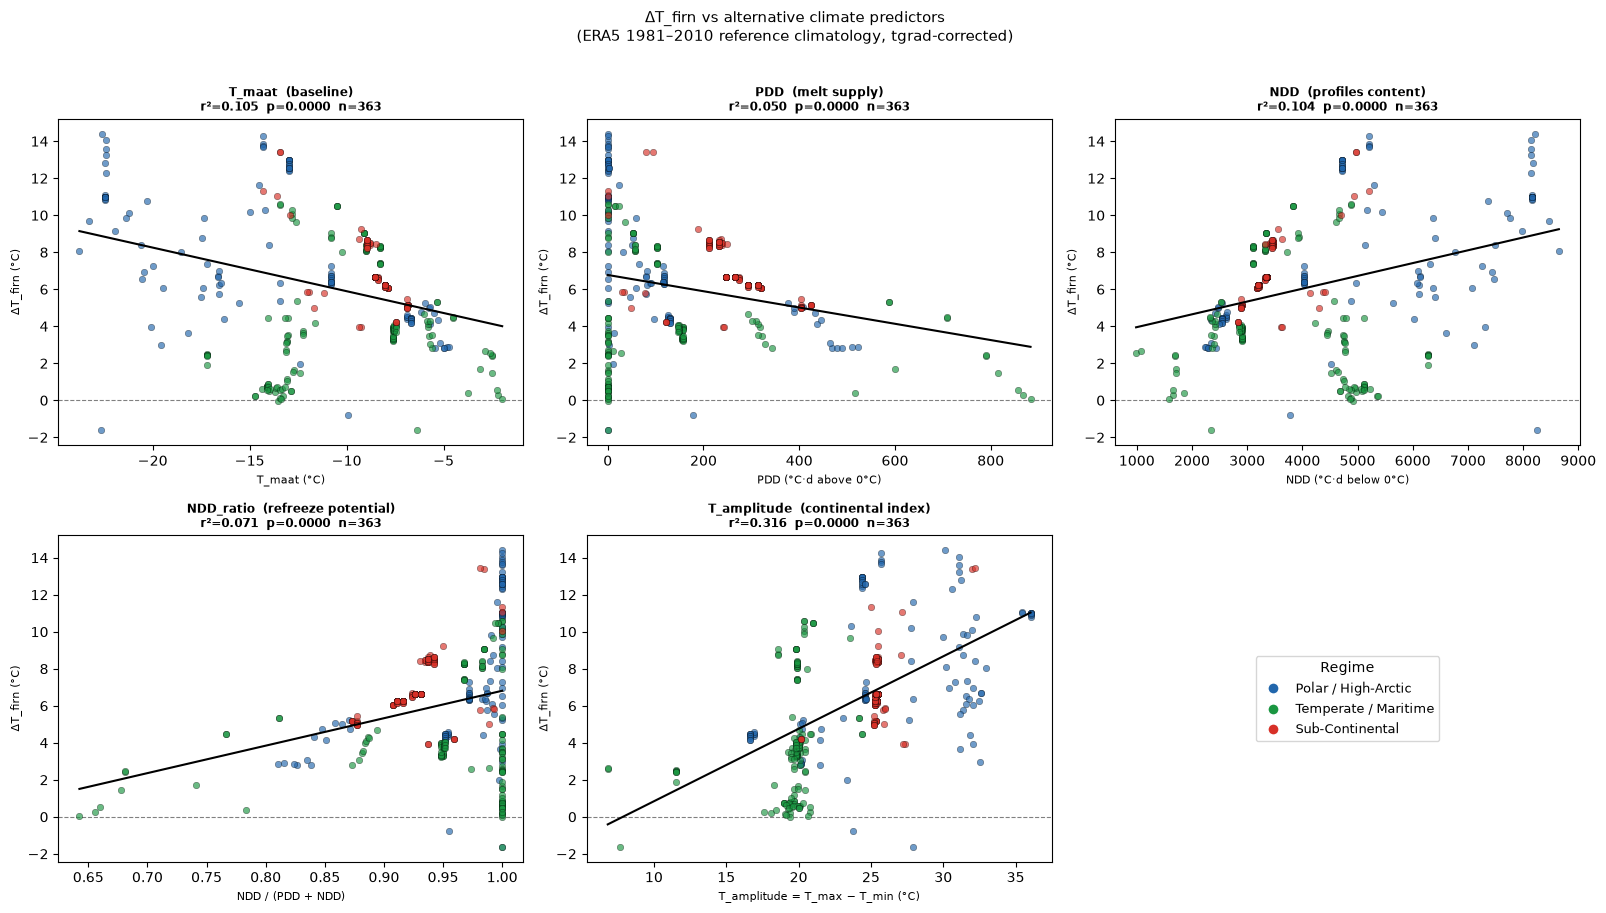

Saved: figures/fig_06_alternative_predictors.pdf

Predictor           r²         p     slope   intercept      n
----------------------------------------------------------
T_amplitude      0.316    0.0000    0.3916     -3.0759    363
T_maat           0.105    0.0000   -0.2357      3.5394    363
NDD              0.104    0.0000    0.0007      3.2627    363
NDD_ratio        0.071    0.0000   14.8357     -8.0236    363
PDD              0.050    0.0000   -0.0044      6.7741    363


In [192]:
# ── Scatter: dT_firn vs each predictor, coloured by regime ───────────────────
pred_info = [
    ('T_maat',      'T_maat (°C)',                     'baseline'),
    ('PDD',         'PDD (°C·d above 0°C)',             'melt supply'),
    ('NDD',         'NDD (°C·d below 0°C)',             'profiles content'),
    ('NDD_ratio',   'NDD / (PDD + NDD)',                'refreeze potential'),
    ('T_amplitude', 'T_amplitude = T_max − T_min (°C)', 'continental index'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = list(axes.ravel())

summary_rows = []
for ax, (col, xlabel, note) in zip(axes_flat, pred_info):
    sub = profiles.dropna(subset=[col, 'dT_firn'])
    for regime in REGIME_ORDER:
        pts = sub[sub['regime'] == regime]
        ax.scatter(pts[col], pts['dT_firn'],
                   color=REGIME_COLORS.get(regime, 'grey'),
                   alpha=0.65, edgecolors='k', linewidths=0.3, s=22,
                   label=regime, zorder=3)

    x_ = sub[col].values
    y_ = sub['dT_firn'].values
    sl, ic, r, p, _ = stats.linregress(x_, y_)
    x_fit = np.linspace(x_.min(), x_.max(), 200)
    ax.plot(x_fit, ic + sl * x_fit, 'k-', lw=1.5, zorder=4)
    ax.axhline(0, color='grey', lw=0.8, ls='--', zorder=2)

    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel('ΔT_firn (°C)', fontsize=8)
    ax.set_title(f'{col}  ({note})\nr²={r**2:.3f}  p={p:.4f}  n={len(sub)}',
                 fontsize=8.5, fontweight='bold')
    summary_rows.append(dict(predictor=col, r2=r**2, p=p, n=len(sub), slope=sl, intercept=ic))

# legend in last (empty) panel
axes_flat[5].axis('off')
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=REGIME_COLORS[r],
                  label=r, markersize=8) for r in REGIME_ORDER]
axes_flat[5].legend(handles=handles, loc='center', fontsize=9, title='Regime')

plt.suptitle('ΔT_firn vs alternative climate predictors\n'
             '(ERA5 1981–2010 reference climatology, tgrad-corrected)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('../figures/fig_06_alternative_predictors.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig_06_alternative_predictors.pdf')

# ── Summary table ─────────────────────────────────────────────────────────────
print()
print(f'{"Predictor":<14}  {"r²":>6}  {"p":>8}  {"slope":>8}  {"intercept":>10}  {"n":>5}')
print('-' * 58)
for row in sorted(summary_rows, key=lambda x: -x['r2']):
    print(f"{row['predictor']:<14}  {row['r2']:>6.3f}  {row['p']:>8.4f}  "
          f"{row['slope']:>8.4f}  {row['intercept']:>10.4f}  {row['n']:>5}")

Statistical outliers (|std_resid| > 2.5):  n = 2
   glacier_name  borehole_id              regime  T_shallow     T_maat   dT_firn  T_amplitude  elevation
Agassiz Ice Cap          240 Polar / High-Arctic    -24.305 -22.674067 -1.630933    27.907803     1670.0
      Vestfonna          638 Polar / High-Arctic     -0.066 -14.324295 14.258295    25.720411      622.0

Near-PMP (T_shallow > -0.5 °C):  n = 53
Ablation zone (T_shallow ok):             n = 102
Total removed:                            n = 155

T_amplitude → ΔT_firn:
  Full dataset:            r² = 0.316  n = 363
  Near-PMP + ablation out: r² = 0.479  n = 208



/tmp/ipykernel_1161077/2577524041.py:55: UserWarning: You passed an edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(pts_out['T_amplitude'], pts_out['dT_firn'],
/tmp/ipykernel_1161077/2577524041.py:55: UserWarning: You passed an edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(pts_out['T_amplitude'], pts_out['dT_firn'],
/tmp/ipykernel_1161077/2577524041.py:55: UserWarning: You passed an edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(pts_out['T_amplitude'], pts_out['dT_firn'],


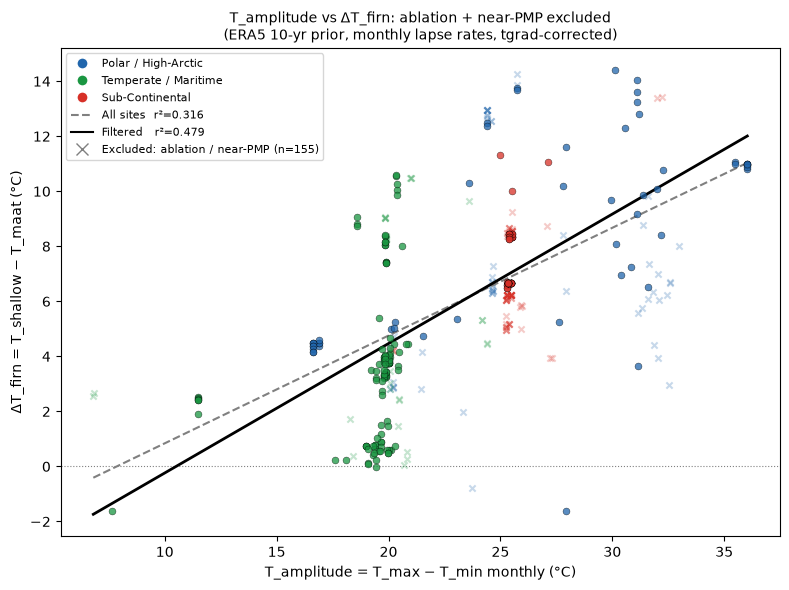

Saved: figures/fig_06b_amplitude_filtered.pdf


In [193]:
# ── Outlier investigation: T_amplitude vs ΔT_firn ────────────────────────────
from scipy import stats as _stats
from matplotlib.lines import Line2D

sub = profiles.dropna(subset=['T_amplitude', 'dT_firn']).copy()
sl, ic, r, p, _ = _stats.linregress(sub['T_amplitude'], sub['dT_firn'])
y_hat     = ic + sl * sub['T_amplitude']
residuals = sub['dT_firn'].values - y_hat.values
std_resid = residuals / residuals.std()
sub['std_resid'] = std_resid

# ── 1. Statistical outliers ───────────────────────────────────────────────────
RESID_THRESH = 2.5
stat_out = sub[abs(sub['std_resid']) > RESID_THRESH].copy()
print(f'Statistical outliers (|std_resid| > {RESID_THRESH}):  n = {len(stat_out)}')
if len(stat_out):
    cols = ['glacier_name', 'borehole_id', 'regime', 'T_shallow',
            'T_maat', 'dT_firn', 'T_amplitude', 'elevation']
    print(stat_out[cols].to_string(index=False))
print()

# ── 2. Filters ────────────────────────────────────────────────────────────────
PMP_THRESH = -0.5   # T_shallow > this → near PMP, ΔT_firn artificially suppressed
profiles_filt = sub[
    (sub['T_shallow'] <= PMP_THRESH) &
    (sub['mass_balance_area'] != 'ablation')
].copy()

n_removed = len(sub) - len(profiles_filt)
near_pmp  = sub[sub['T_shallow'] > PMP_THRESH]
ablation  = sub[(sub['T_shallow'] <= PMP_THRESH) & (sub['mass_balance_area'] == 'ablation')]
print(f'Near-PMP (T_shallow > {PMP_THRESH} °C):  n = {len(near_pmp)}')
print(f'Ablation zone (T_shallow ok):             n = {len(ablation)}')
print(f'Total removed:                            n = {n_removed}')
print()

# ── 3. Filtered regression ────────────────────────────────────────────────────
sl_f, ic_f, r_f, p_f, _ = _stats.linregress(
    profiles_filt['T_amplitude'], profiles_filt['dT_firn'])
print(f'T_amplitude → ΔT_firn:')
print(f'  Full dataset:            r² = {r**2:.3f}  n = {len(sub)}')
print(f'  Near-PMP + ablation out: r² = {r_f**2:.3f}  n = {len(profiles_filt)}')
print()

# ── 4. Replot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

excluded_mask = (sub['T_shallow'] > PMP_THRESH) | (sub['mass_balance_area'] == 'ablation')
for regime in REGIME_ORDER:
    col = REGIME_COLORS.get(regime, 'grey')
    pts_in  = profiles_filt[profiles_filt['regime'] == regime]
    pts_out = sub[(sub['regime'] == regime) & excluded_mask]
    ax.scatter(pts_in['T_amplitude'],  pts_in['dT_firn'],
               color=col, alpha=0.75, edgecolors='k', linewidths=0.3, s=25, zorder=3)
    ax.scatter(pts_out['T_amplitude'], pts_out['dT_firn'],
               color=col, alpha=0.25, edgecolors='none', s=20, marker='x', zorder=2)

x_fit = np.linspace(sub['T_amplitude'].min(), sub['T_amplitude'].max(), 200)
ax.plot(x_fit, ic   + sl   * x_fit, color='grey', ls='--', lw=1.5,
        label=f'All sites  r²={r**2:.3f}  n={len(sub)}')
ax.plot(x_fit, ic_f + sl_f * x_fit, color='k',    ls='-',  lw=2,
        label=f'Filtered   r²={r_f**2:.3f}  n={len(profiles_filt)}')
ax.axhline(0, color='grey', lw=0.8, ls=':', zorder=1)

handles = [Line2D([0],[0], marker='o', color='w',
                  markerfacecolor=REGIME_COLORS[r], label=r, markersize=8)
           for r in REGIME_ORDER]
handles += [
    Line2D([0],[0], color='grey', ls='--', label=f'All sites  r²={r**2:.3f}'),
    Line2D([0],[0], color='k',    ls='-',  label=f'Filtered   r²={r_f**2:.3f}'),
    Line2D([0],[0], marker='x', color='grey', ls='none',
           label=f'Excluded: ablation / near-PMP (n={n_removed})', markersize=8),
]
ax.legend(handles=handles, fontsize=8, loc='upper left')
ax.set_xlabel('T_amplitude = T_max − T_min monthly (°C)', fontsize=10)
ax.set_ylabel('ΔT_firn = T_shallow − T_maat (°C)', fontsize=10)
ax.set_title('T_amplitude vs ΔT_firn: ablation + near-PMP excluded\n'
             f'(ERA5 {LOOKBACK_YRS}-yr prior, monthly lapse rates, tgrad-corrected)',
             fontsize=10)
plt.tight_layout()
plt.savefig('../figures/fig_06b_amplitude_filtered.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig_06b_amplitude_filtered.pdf')


In [194]:
# ── Multi-predictor OLS: all 5 predictors jointly ────────────────────────────
from scipy.stats import zscore

pred_cols = ['T_maat', 'PDD', 'NDD', 'NDD_ratio', 'T_amplitude']
sub_multi = profiles.dropna(subset=pred_cols + ['dT_firn']).copy()
y_multi   = sub_multi['dT_firn'].values

# ── Raw OLS (same subset as multi-predictor, for fair r² comparison) ──────────
print(f'Common subset (no NaNs in any predictor): n = {len(sub_multi)}')
print()
print(f'{"Predictor":<14}  {"r²(single)":>10}  {"p":>8}')
print('-' * 38)
single_r2 = {}
for col in pred_cols:
    x_ = sub_multi[col].values
    sl_, ic_, r_, p_, _ = stats.linregress(x_, y_multi)
    single_r2[col] = r_**2
    print(f'{col:<14}  {r_**2:>10.3f}  {p_:>8.4f}')

# ── Combined OLS ──────────────────────────────────────────────────────────────
X_raw = np.column_stack([np.ones(len(sub_multi))] +
                         [sub_multi[c].values for c in pred_cols])
coeffs_raw, _, _, _ = np.linalg.lstsq(X_raw, y_multi, rcond=None)
y_pred_multi = X_raw @ coeffs_raw
ss_tot  = ((y_multi - y_multi.mean()) ** 2).sum()
ss_res  = ((y_multi - y_pred_multi) ** 2).sum()
R2_multi = 1 - ss_res / ss_tot

print()
print(f'Combined 5-predictor OLS  R² = {R2_multi:.3f}  (n = {len(sub_multi)})')
print()

# ── Standardised coefficients (feature importance) ────────────────────────────
X_std = np.column_stack([np.ones(len(sub_multi))] +
                         [zscore(sub_multi[c].values) for c in pred_cols])
coeffs_std, _, _, _ = np.linalg.lstsq(X_std, y_multi, rcond=None)

print('Standardised coefficients (|value| = relative importance):')
print(f'  {"intercept":<14}  {coeffs_std[0]:>+8.3f}')
for col, cs in zip(pred_cols, coeffs_std[1:]):
    print(f'  {col:<14}  {cs:>+8.3f}')

Common subset (no NaNs in any predictor): n = 363

Predictor       r²(single)         p
--------------------------------------
T_maat               0.105    0.0000
PDD                  0.050    0.0000
NDD                  0.104    0.0000
NDD_ratio            0.071    0.0000
T_amplitude          0.316    0.0000

Combined 5-predictor OLS  R² = 0.509  (n = 363)

Standardised coefficients (|value| = relative importance):
  intercept         +6.079
  T_maat          +609.264
  PDD              -67.989
  NDD             +563.564
  NDD_ratio         -4.056
  T_amplitude       +5.634


In [195]:
# ── Fit C&P profile shape (ΔT(z) = A × exp(−z/z0)) per borehole ─────────────
from scipy.optimize import curve_fit

def _cp_shape(z, A, z0):
    return A * np.exp(-z / z0)

MIN_PTS  = 4      # minimum measurements per borehole
MIN_SPAN = 10.0   # minimum depth range (m)
Z_MIN    = 5.0    # shallowest measurement to include (m)
Z_MAX    = 80.0   # deepest measurement to include (m)
MIN_DT   = 0.2    # minimum surface ΔT to attempt fit

z0_rows = []
for bid in profiles['borehole_id']:
    row = profiles[profiles['borehole_id'] == bid].iloc[0]
    T_maat_b = row['T_maat']
    regime_b = row['regime']
    if np.isnan(T_maat_b):
        continue

    sub = meas_all[
        (meas_all['borehole_id'] == bid) &
        (meas_all['depth'].between(Z_MIN, Z_MAX)) &
        (meas_all['temperature'].notna())
    ].copy()
    sub = sub.sort_values('depth')
    if len(sub) < MIN_PTS:
        continue
    if sub['depth'].max() - sub['depth'].min() < MIN_SPAN:
        continue

    z_arr  = sub['depth'].values
    dT_arr = sub['temperature'].values - T_maat_b
    if dT_arr.max() < MIN_DT:
        continue

    try:
        popt, pcov = curve_fit(
            _cp_shape, z_arr, dT_arr,
            p0=[dT_arr.max(), 15.0],
            bounds=([0.5, 2.0], [30.0, 150.0]),
            maxfev=2000,
        )
        A_fit, z0_fit = popt
        A_err, z0_err = np.sqrt(np.diag(pcov))
        z0_rows.append({
            'borehole_id': bid,
            'regime':      regime_b,
            'z0_fit':      z0_fit,
            'z0_err':      z0_err,
            'A_fit':       A_fit,
            'A_err':       A_err,
            'n_pts':       len(sub),
        })
    except (RuntimeError, ValueError):
        pass

z0_df = pd.DataFrame(z0_rows)
print(f'Boreholes attempted: {profiles["borehole_id"].nunique()}')
print(f'Successful fits:     {len(z0_df)}')
print()

for r in REGIME_ORDER:
    sub_r = z0_df[z0_df['regime'] == r]
    if len(sub_r) < 3:
        print(f'{r}: n={len(sub_r)} — too few fits')
        continue
    print(f'{r}  (n={len(sub_r)})')
    print(f'  z0: median={sub_r["z0_fit"].median():.1f} m   '
          f'IQR=[{sub_r["z0_fit"].quantile(0.25):.1f}, {sub_r["z0_fit"].quantile(0.75):.1f}]')
    print(f'   A: median={sub_r["A_fit"].median():.2f} °C  '
          f'IQR=[{sub_r["A_fit"].quantile(0.25):.2f}, {sub_r["A_fit"].quantile(0.75):.2f}]')
    print()

Boreholes attempted: 126
Successful fits:     254

Polar / High-Arctic  (n=47)
  z0: median=150.0 m   IQR=[150.0, 150.0]
   A: median=6.80 °C  IQR=[5.54, 10.61]

Temperate / Maritime  (n=97)
  z0: median=150.0 m   IQR=[150.0, 150.0]
   A: median=4.10 °C  IQR=[1.40, 8.56]

Sub-Continental  (n=110)
  z0: median=150.0 m   IQR=[150.0, 150.0]
   A: median=6.59 °C  IQR=[5.90, 9.07]



Well-constrained fits (z0_err/z0 < 100%): 213



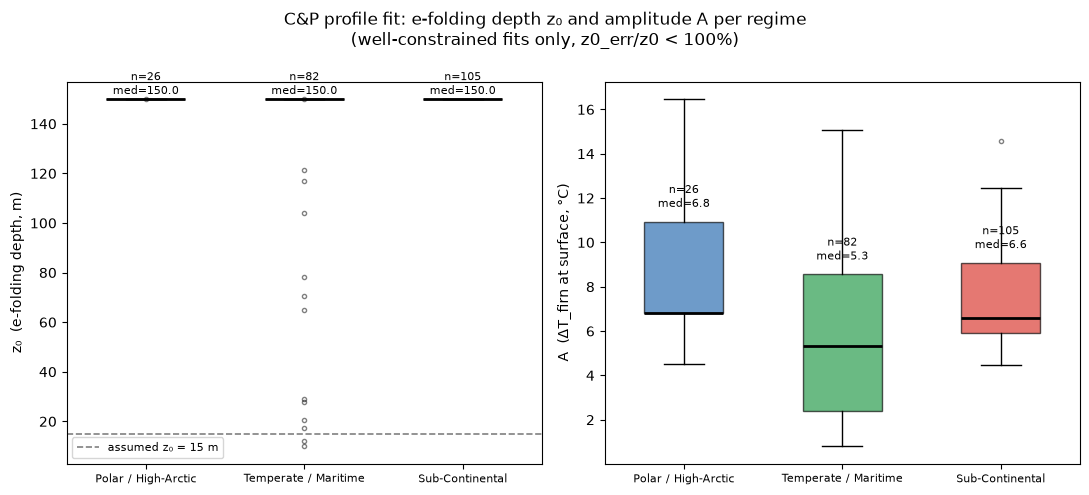

Saved: figures/fig_08_z0_fit.pdf


In [196]:
# ── Plot: z0 and A (amplitude) distributions per regime ──────────────────────
if 'z0_df' in dir() and len(z0_df) >= 3:
    z0_good = z0_df[(z0_df['z0_err'] / z0_df['z0_fit']) < 1.0].copy()
    print(f'Well-constrained fits (z0_err/z0 < 100%): {len(z0_good)}')
    print()

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    for ax, col, label, ref_val, ref_lbl in zip(
        axes,
        ['z0_fit',                    'A_fit'],
        ['z₀  (e-folding depth, m)', 'A  (ΔT_firn at surface, °C)'],
        [15.0,                        None],
        ['assumed z₀ = 15 m',         None],
    ):
        data_r = [z0_good[z0_good['regime'] == r][col].dropna().values
                  for r in REGIME_ORDER]
        labs_r = [r for r, d in zip(REGIME_ORDER, data_r) if len(d) >= 3]
        data_r = [d for d in data_r if len(d) >= 3]
        if not data_r:
            ax.text(0.5, 0.5, 'insufficient data', ha='center', va='center',
                    transform=ax.transAxes)
            continue
        bp = ax.boxplot(data_r, tick_labels=labs_r, patch_artist=True,
                        medianprops=dict(color='k', lw=2), widths=0.5,
                        flierprops=dict(marker='o', markersize=3, alpha=0.5))
        for patch, r in zip(bp['boxes'], labs_r):
            patch.set_facecolor(REGIME_COLORS.get(r, 'grey'))
            patch.set_alpha(0.65)
        for i, (lbl, d) in enumerate(zip(labs_r, data_r), start=1):
            ax.text(i, np.percentile(d, 75) + 0.5,
                    f'n={len(d)}\nmed={np.median(d):.1f}',
                    ha='center', va='bottom', fontsize=8)
        if ref_val is not None:
            ax.axhline(ref_val, color='grey', ls='--', lw=1.2, label=ref_lbl)
            ax.legend(fontsize=8)
        ax.set_ylabel(label)
        ax.tick_params(axis='x', labelsize=8)

    plt.suptitle('C&P profile fit: e-folding depth z₀ and amplitude A per regime\n'
                 '(well-constrained fits only, z0_err/z0 < 100%)')
    plt.tight_layout()
    plt.savefig('../figures/fig_08_z0_fit.pdf', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: figures/fig_08_z0_fit.pdf')
else:
    print('z0_df not available or too few fits — run the C&P fitting cell first.')

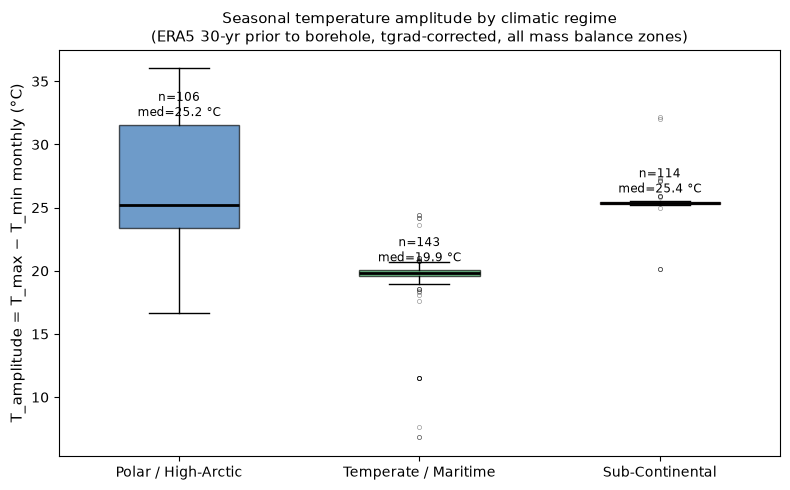

Saved: figures/fig_07_T_amplitude_boxplot.pdf

Regime                        n    mean     std     p25     med     p75
-----------------------------------------------------------------
Polar / High-Arctic         106    26.6     5.7    23.4    25.2    31.5
Temperate / Maritime        143    19.4     2.6    19.6    19.9    20.0
Sub-Continental             114    25.4     1.3    25.3    25.4    25.5


In [197]:
# ── Boxplot: T_amplitude per climatic regime ──────────────────────────────────
sub_amp = profiles.dropna(subset=['T_amplitude'])

data_amp   = [sub_amp[sub_amp['regime'] == r]['T_amplitude'].values for r in REGIME_ORDER]
labels_amp = [r for r, d in zip(REGIME_ORDER, data_amp) if len(d) >= 3]
data_amp   = [d for d in data_amp if len(d) >= 3]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(data_amp, tick_labels=labels_amp, patch_artist=True,
                medianprops=dict(color='k', lw=2), widths=0.5,
                flierprops=dict(marker='o', markersize=3, alpha=0.4,
                                markeredgewidth=0.5))
for patch, lbl in zip(bp['boxes'], labels_amp):
    patch.set_facecolor(REGIME_COLORS[lbl])
    patch.set_alpha(0.65)

for i, (lbl, d) in enumerate(zip(labels_amp, data_amp), start=1):
    ax.text(i, np.percentile(d, 75) + 0.4,
            f'n={len(d)}\nmed={np.median(d):.1f} °C',
            ha='center', va='bottom', fontsize=8.5)

ax.set_ylabel('T_amplitude = T_max − T_min monthly (°C)', fontsize=11)
ax.set_title('Seasonal temperature amplitude by climatic regime\n'
             '(ERA5 30-yr prior to borehole, tgrad-corrected, all mass balance zones)',
             fontsize=11)
ax.tick_params(axis='x', labelsize=10)
plt.tight_layout()
plt.savefig('../figures/fig_07_T_amplitude_boxplot.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig_07_T_amplitude_boxplot.pdf')

print()
print(f'{"Regime":<25}  {"n":>4}  {"mean":>6}  {"std":>6}  {"p25":>6}  {"med":>6}  {"p75":>6}')
print('-' * 65)
for lbl, d in zip(labels_amp, data_amp):
    print(f'{lbl:<25}  {len(d):>4}  {np.mean(d):>6.1f}  {np.std(d):>6.1f}  '
          f'{np.percentile(d,25):>6.1f}  {np.median(d):>6.1f}  {np.percentile(d,75):>6.1f}')


In [198]:
# ── Export profiles dataframe for ML notebook (02_glenglat_ML.ipynb) ────────
# Exports the full profiles dataframe with all ERA5-derived columns.
# Run this cell after Section 7 (cells 31-37) to refresh the CSV.

EXPORT_CSV = '../data/glenglat_profiles_derived.csv'
profiles.to_csv(EXPORT_CSV, index=False)
print(f'Exported {len(profiles)} profiles → {EXPORT_CSV}')
print(f'Columns: {list(profiles.columns)}')


Exported 363 profiles → ../data/glenglat_profiles_derived.csv
Columns: ['borehole_id', 'profile_id', 'glacier_name', 'latitude', 'longitude', 'elevation', 'mass_balance_area', 'regime', 'glogem_region', 'T_maat', 'profile_date_min', 'T_shallow_depth', 'T_shallow', 'dT_firn', 'PDD', 'NDD', 'NDD_ratio', 'T_amplitude']
